# **Predict Ames Homes Prices ---- Advanced Regression Technique**

<a id="section_ID"></a> <br>
 # Table of Contents
 1. [Introduction](#1)
    1. [Business Objective](#7)
    2. [Problem Statement](#8)
2. [Exploratory Data Anlaysis](#2)
   1. [Data Ingestion & Understanding](#7)
   2. [Univariate & Multivariate Feature Analysis](#8)

# __Introduction__

The Ames Housing dataset, created by Dean De Cock for educational use in data science, contains detailed records of residential property sales in Ames, Iowa between 2006 and 2010. It includes 2,919 observations and a rich set of explanatory variables: 23 nominal, 23 ordinal, 14 discrete, and 20 continuous features, all designed to capture the many factors that influence home values.

# Business Objective

In today's dynamic real estate market, accurate house price prediction is crucial for various stakeholders:
 - **Home Buyers** : Want to ensure making fair offers.
 - **Sellers** : Need to set compeitive listing prices.
 - **Real Estate Agents** : Need reliable price estimates to advise clinets effectively.
 - **Investors** : Require accurate valuation for investment decisions.

# Problem Statement
This project implements a machine learning solution to analyze various house dimensions to predict sale prices, helping stakeholders to make data-driven decisions.

## __Import Libraries__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
#import dvc 
import kaggle
import os
import zipfile
from pathlib import Path

%matplotlib inline
sns.set_style('darkgrid')


# __Display Settings__

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## __Data Ingestion & Understanding__

In [3]:
from pathlib import Path
import pandas as pd
files = []
path_data = Path.cwd().parent.joinpath("data", "raw")
for file in path_data.rglob("*.csv"):
    files.append(file)
    print(file.name)
    print(files.index(file), " ", file)

sample_submission.csv
0   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\sample_submission.csv
test.csv
1   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\test.csv
train.csv
2   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\train.csv


In [4]:
# Load data
train_df = pd.read_csv(files[2])
test_df = pd.read_csv(files[1])
df_train = pd.read_csv(files[2], index_col='Id')
df_test = pd.read_csv(files[1], index_col='Id')

# Save test IDs for later use
test_ids = df_test.index

# Seperate features and target variable
X_train = df_train.drop(['SalePrice'], axis=1)
y = df_train.SalePrice

# Concatenate train and test data
X = pd.concat([X_train, df_test], axis=0)


In [5]:
X.shape

(2919, 79)

In [6]:
# Basic info of datasets
print(f"Training Dataset Shape : {X_train.shape}")
print(f"Testing Dataset Shape : {df_test.shape}")


Training Dataset Shape : (1460, 79)
Testing Dataset Shape : (1459, 79)


In [7]:
# remove whitespace from columns name, replace space to '_' for columns name for conveince

X_train.columns = X_train.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
df_test.columns = df_test.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

In [8]:
# Segregate numerical and categorical features
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
print(f"Total Numerical Columns : {len(num_cols)}\n", num_cols)

Total Numerical Columns : 36
 ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [9]:
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()
print(f"Total Categorical Columns : {len(cat_cols)}\n", cat_cols)

Total Categorical Columns : 43
 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [10]:
dtype_df = pd.DataFrame(index=df_train.columns, columns=['Dtype','nunique','unique'])
dtype_df['Dtype'] = df_train.dtypes
dtype_df['nunique'] = df_train.nunique()
dtype_df['unique'] = [df_train[col].unique() for col in df_train.columns]
dtype_df.head()


,Dtype,nunique,unique
MSSubClass,int64,15,"[60, 20, 70, 50, 190, 45, 90, 120, 30, 85, 80,..."
MSZoning,object,5,"[RL, RM, C (all), FV, RH]"
LotFrontage,float64,110,"[65.0, 80.0, 68.0, 60.0, 84.0, 85.0, 75.0, nan..."
LotArea,int64,1073,"[8450, 9600, 11250, 9550, 14260, 14115, 10084,..."
Street,object,2,"[Pave, Grvl]"


In [11]:
# Store features in different groups based on their data type

ordinal_num_var = ['OverallQual', 'OverallCond', 'BsmtFullBath','BsmtHalfBath',
                   'FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageCars']

convert_cat_var = ['MSSubClass', 'YrSold', 'MoSold']

numeric_var = [col for col in df_train.select_dtypes(include=np.number).columns 
               if col not in ordinal_num_var + convert_cat_var and col != 'SalePrice']

# ordinal categorical features based on quality and condition
ordinal_qual_cond_var = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                         'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']

# ordinal categorical features based on basement and finish types
ordinal_bsmt_fin_var = ['BsmtFinType1', 'BsmtFinType2', 'BsmtExposure', 'GarageFinish']

# ordinal features based on functional and utility 
ordinal_fun_util_var = ['LotShape', 'Fence', 'Functional', 'Utilities']

# nominal categorical features
cat_var = [col for col in df_train.select_dtypes(include=['object']).columns 
           if col not in ordinal_qual_cond_var + ordinal_bsmt_fin_var + ordinal_fun_util_var]


## **2. Exploratory Data Analysis**

#### **2.1. Sale Price**

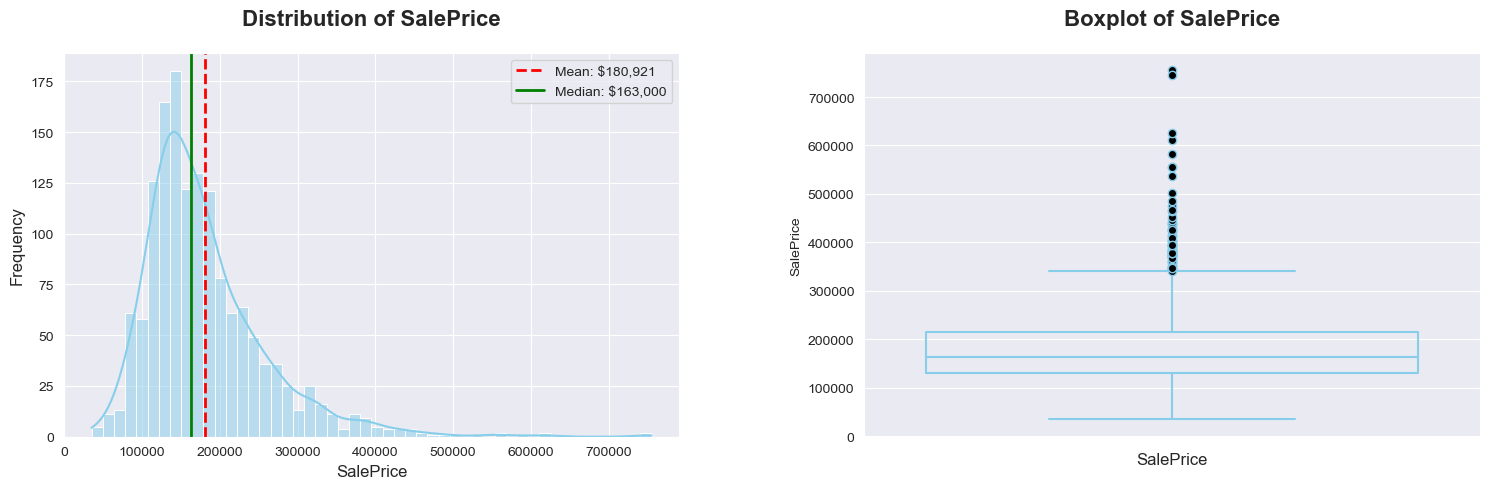

In [12]:
# Calculate statistics
mean_price = y.mean()
median_price = y.median()

# Plot histogram with KDE
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(y, kde=True, bins=50, color='skyblue', ax=ax[0])

# Add mean and median lines
ax[0].axvline(mean_price, color="red", linestyle="--", linewidth=2, label=f"Mean: ${mean_price:,.0f}")
ax[0].axvline(median_price, color="green", linestyle="-", linewidth=2, label=f"Median: ${median_price:,.0f}")

# Labels and legend
fig.subplots_adjust(bottom=0.2)
ax[0].set_title("Distribution of SalePrice", fontsize=16, fontweight='bold', pad=20)
ax[0].set_xlabel("SalePrice", fontsize=12)
ax[0].set_ylabel("Frequency", fontsize=12)
ax[0].legend()


# boxplot of SalePrice for outliers
sns.boxplot(y=df_train['SalePrice'], color='skyblue', fill=False, flierprops={'marker': 'o', 'markerfacecolor':'k'}, ax=ax[1])
ax[1].set_title("Boxplot of SalePrice", fontsize=16, fontweight='bold', pad=20)
ax[1].set_xlabel("SalePrice", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

In [13]:
print(f"""Skewness : {y.skew():.4f}
Kurtosis : {y.kurtosis():.4f}""") # kurtosis > 3 means heavy tails, more outliers than normal.

Skewness : 1.8829
Kurtosis : 6.5363


- The distribution of `SalePrice` is right-skewed. So, we can consider transformation to reduce skewness before modeling.
- Sale prices range form $34,900 to $755,000.


#### **2.2. Numerical Features**

Top 10 numerical features highly correlated with SalePrice:


In [14]:
corr_matrix = df_train.select_dtypes(include=[np.number]).corr()
top_10_corr = corr_matrix['SalePrice'].sort_values(ascending=False).head(11)
top_10_corr

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

__What are the top 10 features selected by Recursive Feature Elimination?__


In [15]:
from sklearn.feature_selection import RFE, f_regression, r_regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=10, step=1)
selector = rfe.fit(X_train.fillna(0).select_dtypes(exclude='object'), y)
selected_features = list(
    X_train.select_dtypes(exclude='object').columns[selector.support_]
)
selected_features

['OverallQual',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars']

Based on the analyses, features such as __Overall Quality, Living Area, Garage Size, Number of Full Baths, and Year Built__ emerge as key determinants of house prices. Let's explore these features in greater detail.

**Overall Quality**

Overall quality is the most important feature in both analyses. It is clear that higher quality makes the house more expensive.



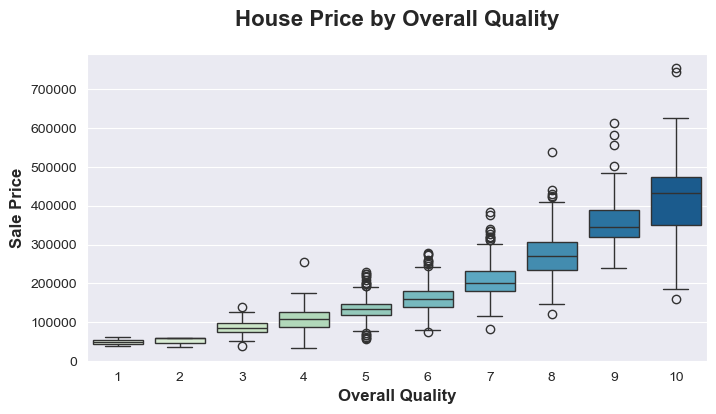

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x='OverallQual', y='SalePrice', data=df_train, palette='GnBu')
ax.set_title('House Price by Overall Quality', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Overall Quality', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.show()


#### **Living Area**

The living area shows a clear linear relationship with house price. In the scatter plot, however, several __outliers__ are evident—most notably two properties in the lower-right corner with more than __4,000 square feet__ of living space but priced below __$200,000__.

Correlation : 0.7086244776126515


<Figure size 600x400 with 0 Axes>

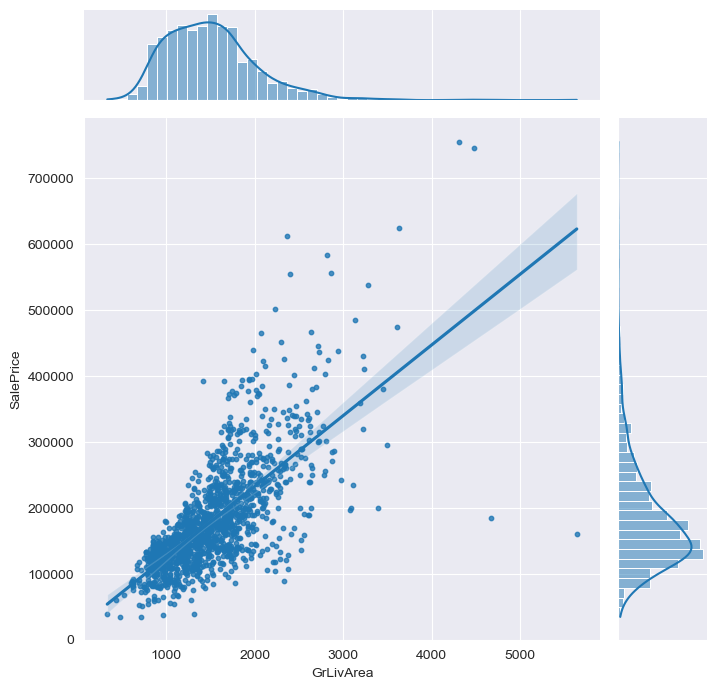

In [17]:
def plot_correlation(features):
    """
    1. Plot correlation of two features
    2. Create Joint plot of two features
    """
    # print correlation
    print("Correlation :", df_train[[features[0], features[1]]].corr().iloc[1, 0])

    # Create joint plot
    plt.figure(figsize=(6, 4))
    sns.jointplot(data = df_train, x= features[0], y=features[1], kind='reg', height=7, scatter_kws={'s': 10}, marginal_kws={'kde': True})
    

plot_correlation(['GrLivArea', 'SalePrice'])
plt.show()

#### **GarageCars**

It's surprising that houses with __four-car garages__ are actually priced lower than those with __three-car garages__.

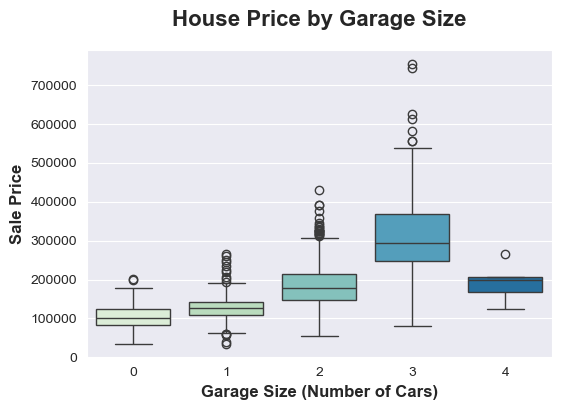

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='GarageCars', y='SalePrice', data=df_train, palette='GnBu', ax=ax)
ax.set_title('House Price by Garage Size', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax.set_xlabel('Garage Size (Number of Cars)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.show()


#### **Year Built**

The age of a house is another key factor influencing its price. In general, newer homes command higher average values, though there are also several pre‑1900 properties that stand out with notably high prices.

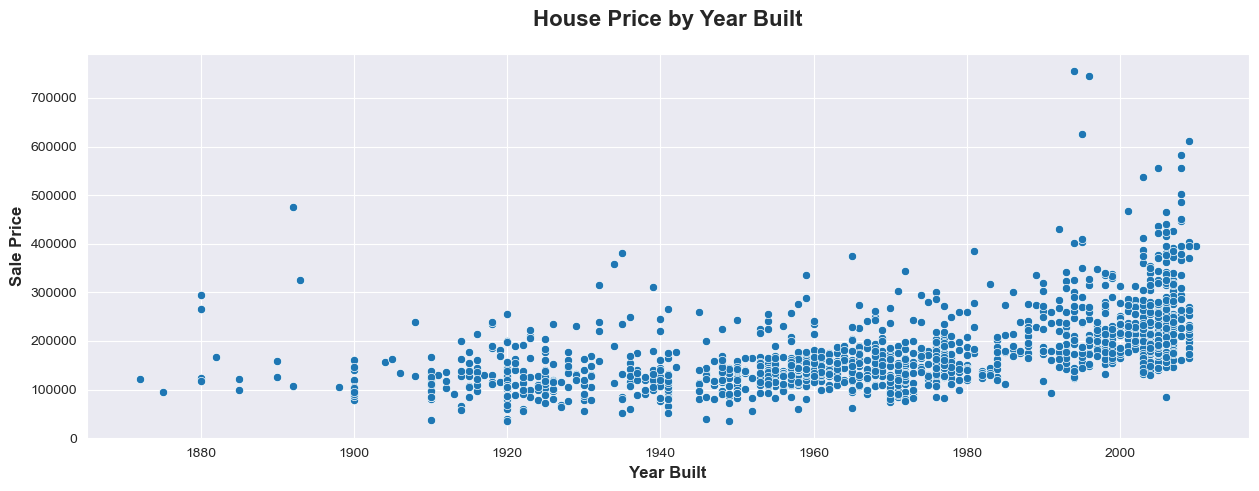

In [19]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.scatterplot(x='YearBuilt', y='SalePrice', data=df_train, ax=ax)
ax.set_title('House Price by Year Built', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax.set_xlabel('Year Built', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.show()


#### **2.3. Categorical Variables**

In [20]:
from sklearn.preprocessing import LabelEncoder
from scipy import stats
# Select Categorical features
import pandas as pd
from scipy import stats

# Select categorical features
cat_columns = df_train.select_dtypes(include='object').columns
target_data = df_train['SalePrice']

# Store results
results = []

for col in cat_columns:
    # Only consider categorical features with more than 3 unique values
    if len(df_train[col].unique()) > 2:
        groups = [target_data[df_train[col] == category] 
                  for category in df_train[col].unique()]
        # Perform ANOVA test
        f_value, p_value = stats.f_oneway(*groups)
        
        # Append the results to the list
        results.append({
            'Feature': col,
            'F_value': np.round(f_value, 2),
            'P_value': np.round(p_value, 6)
        })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Sort by F_value (descending) and then by P_value (ascending)
results_df = results_df.sort_values(by=['F_value'], 
                                    ascending=[False]).reset_index(drop=True)

# Select top 10 features
print(results_df.query("P_value < 0.01").head())


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\scipy\stats\_stats_py.py:4102: DegenerateDataWarning: at least one input has length 0
  if _f_oneway_is_too_small(samples):


        Feature  F_value  P_value
0     ExterQual   443.33      0.0
1   KitchenQual   407.81      0.0
2    Foundation   100.25      0.0
3     HeatingQC    88.39      0.0
4  Neighborhood    71.78      0.0


__Interpretation :__

__1. ExterQual (F = 443.33, p ~ 0)__

    - Exterior quality has a very strong effect on house prices.

    - Homes with better exterior materials/quality sell for significantly higher prices.

__2. KitchenQual (F = 407.81, p ~ 0)__

    - Kitchen quality is another major driver of sale price.

    - Buyers place high value on kitchen finishes and condition.

__3. Foundation (F = 100.25, p ~ 0)__

    - The type of foundation (e.g., basement, crawl space, slab) significantly influences price.

    - Certain foundation types are associated with higher-value homes.

__4. HeatingQC (F = 88.39, p ~ 0)__

    - Heating quality also matters.

    - Better heating systems correlate with higher sale prices.

__5. Neighborhood (F = 71.78, p ~ 0)__

    - Location within Ames strongly affects price.

    - Different neighborhoods explains significant price variation.

In [21]:
# Select features with F_value > 50 , P_value < 0.01 
# drop those features whose f_value < 50 Because those features are not enough to likely predict saleprice
results_df.query("F_value >= 50 and P_value < 0.01")[['Feature', 'F_value', 'P_value']]

,Feature,F_value,P_value
0,ExterQual,443.33,0.0
1,KitchenQual,407.81,0.0
2,Foundation,100.25,0.0
3,HeatingQC,88.39,0.0
4,Neighborhood,71.78,0.0


In [22]:
'Neighborhood',
'MasVnrType',
'Foundation',
'CentralAir',
'Electrical',
'GarageType',
'MiscFeature' in results_df['Feature'].values


True

In [23]:
cat_var = ['Neighborhood',
'MasVnrType',
'Foundation',
'Electrical',
'GarageType',
'MiscFeature']
results_df[results_df['Feature'].isin(cat_var)]

,Feature,F_value,P_value
2,Foundation,100.25,0.0
4,Neighborhood,71.78,0.0
25,MasVnrType,NaN,NaN
31,Electrical,NaN,NaN
33,GarageType,NaN,NaN
39,MiscFeature,NaN,NaN


In [24]:
cat_feat_remove = results_df.query("F_value < 50")['Feature'].tolist()
# drop those as well where fvalue is NaN because those features are not likely to predict saleprice and pvalue is also NaN
remove_cat = cat_feat_remove + ['MasVnrType', 'Electrical', 'GarageType', 'MiscFeature']

**t-test of categorical features with respect to the target variable**

In [25]:
from scipy.stats import ttest_ind

train = df_train.copy()
features = ['Street', 'Alley', 'Utilities', 'CentralAir']
results = []

for col in features:
    # Fill NaN with mode
    mode_value = train[col].mode()[0]
    train[col] = train[col].fillna(mode_value)
    
    # Get categories
    categories = train[col].unique()
    
    if len(categories) == 2:  # valid for binary categorical
        group1 = train.loc[train[col] == categories[0], "SalePrice"]
        group2 = train.loc[train[col] == categories[1], "SalePrice"]
        
        # Only run if both groups have at least 2 samples
        if len(group1) > 1 and len(group2) > 1:
            t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
            results.append({"Feature": col, "t_stat": t_stat, "p_value": p_val})
        else:
            results.append({"Feature": col, "t_stat": "N/A", "p_value": "N/A"})
    else:
        results.append({"Feature": col, "t_stat": "N/A", "p_value": "N/A"})

# Display results
ttest_df = pd.DataFrame(results)
print(ttest_df)

      Feature     t_stat   p_value
0      Street   1.900788  0.115048
1       Alley   2.090158  0.041634
2   Utilities        N/A       N/A
3  CentralAir  17.267773       0.0


In [26]:
ttest_df.loc[ttest_df['Feature'] != 'Utilities', :].query("p_value < 0.01")

,Feature,t_stat,p_value
3,CentralAir,17.267773,0.0


In [27]:
remove_cols = ['Utilities', 'Street', 'Alley']

#### **2.4. Bivariate Plots ---- Impact of Log and Square Transformations on Linearity**

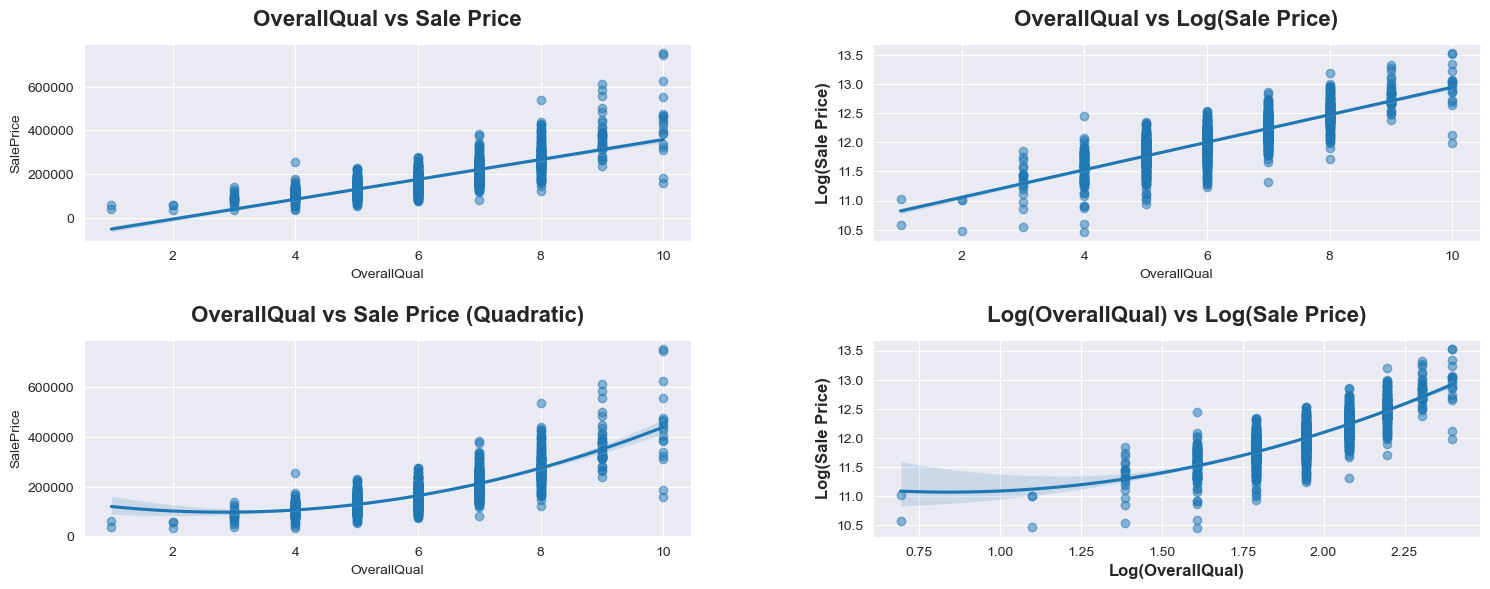

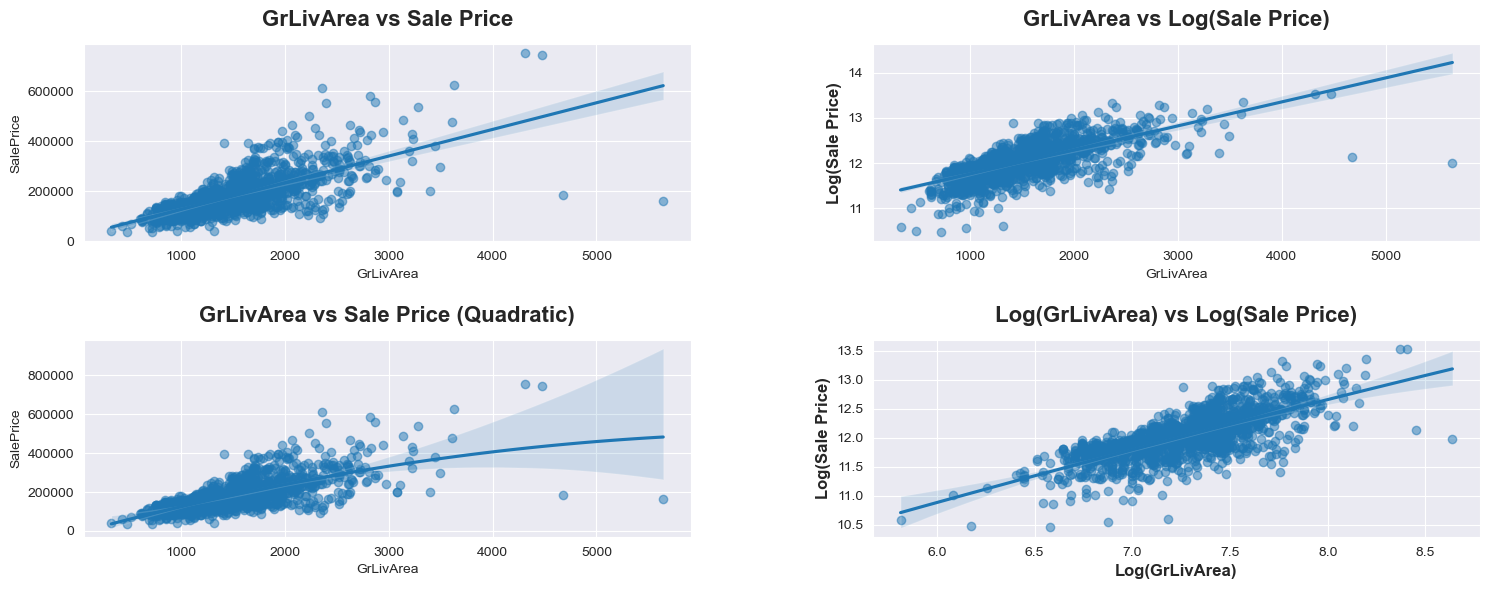

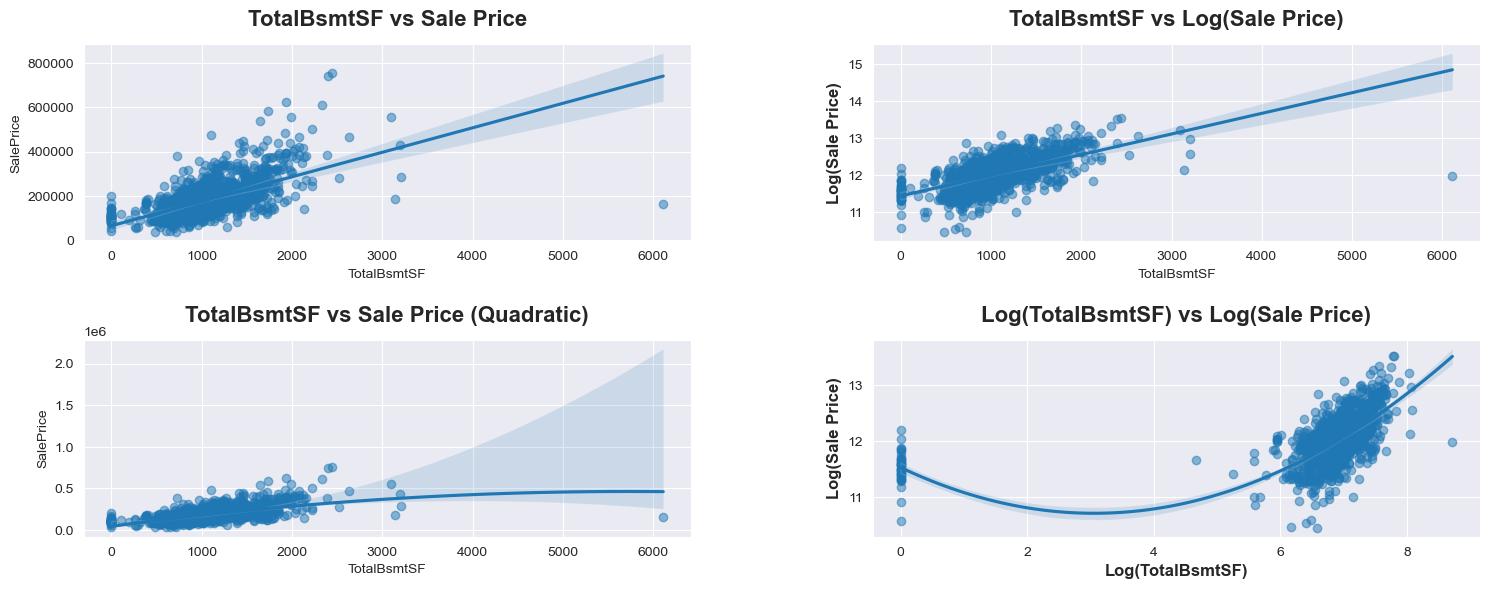

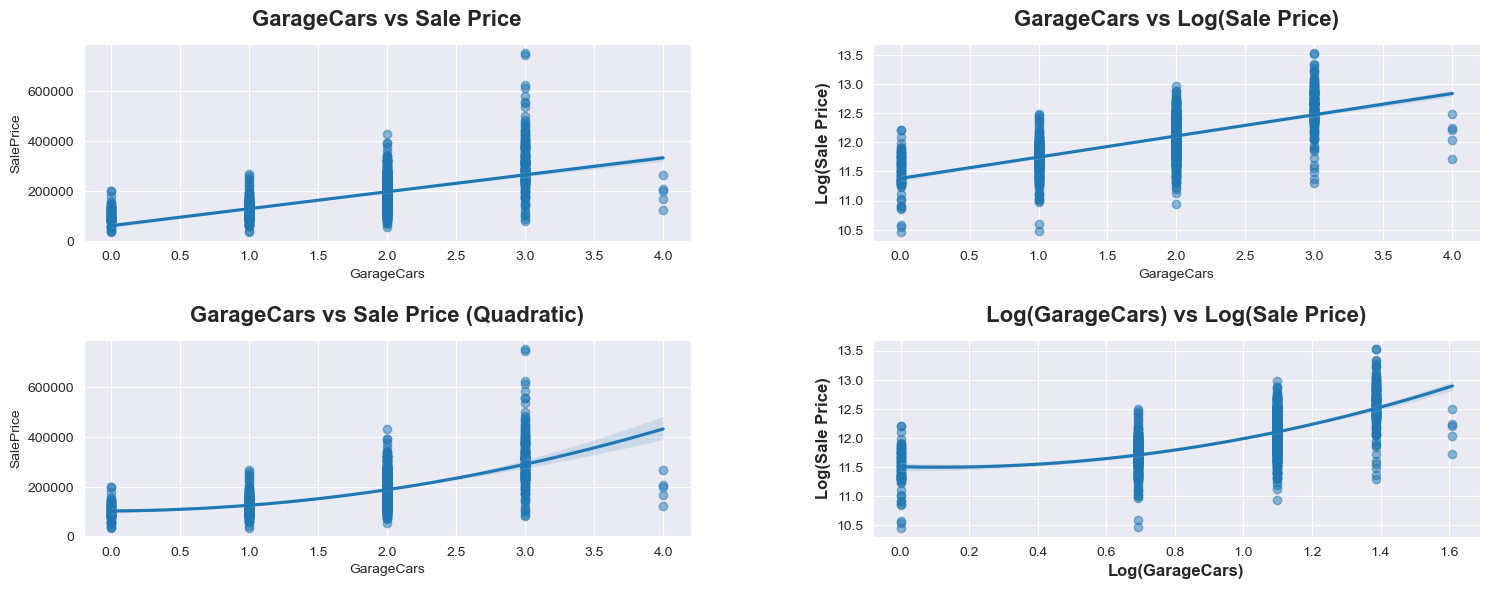

In [28]:

def plot_scatter(feature):
    fig, ax = plt.subplots(2, 2, figsize=(15, 6))
    
    # Linear relationship
    sns.regplot(x=feature, y='SalePrice', data=df_train, scatter_kws={'alpha':0.5}, ax=ax[0,0])
    ax[0,0].set_title(f'{feature} vs Sale Price', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
    
    # Log transformation of target
    sns.regplot(x=feature, y=np.log1p(df_train['SalePrice']), data=df_train, scatter_kws={'alpha':0.5}, ax=ax[0,1])
    ax[0,1].set_title(f'{feature} vs Log(Sale Price)', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
    ax[0, 1].set_ylabel('Log(Sale Price)', fontsize=12, fontweight='bold')
    
    # Non-linear fit (lowess smoothing)
    sns.regplot(x=feature, y='SalePrice', data=df_train, scatter_kws={'alpha':0.5}, order=2, ax=ax[1,0])
    ax[1,0].set_title(f'{feature} vs Sale Price (Quadratic)', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
    
    # Log transformation of feature and target
    sns.regplot(x=np.log1p(df_train[feature]), y=np.log1p(df_train['SalePrice']), data=df_train, scatter_kws={'alpha':0.5}, order=2, ax=ax[1,1])
    ax[1,1].set_title(f'Log({feature}) vs Log(Sale Price)', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
    ax[1, 1].set_xlabel(f'Log({feature})', fontsize=12, fontweight='bold')
    ax[1, 1].set_ylabel('Log(Sale Price)', fontsize=12, fontweight='bold')
    
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.5)
    plt.show()

# Plot key numeric features
important_numerics = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars']
for feature in important_numerics:
    plot_scatter(feature)

**Key Findings :**

- OverallQual is strongly linearly related to SalePrice, but with a slight non-linear boost at the highest ratings.
- GrLivArea has a strong positive linear relationship with SalePrice, but there are some outliers with very large living area that do not follow the trend.
- Total Basement Square Feet needs log transformation for more linear relationship.
- GarageCars has a positive relationship with SalePrice, but the relationship is not strictly linear, especially for houses with 3 or more garage spaces.

#### **2.5. Correlations**

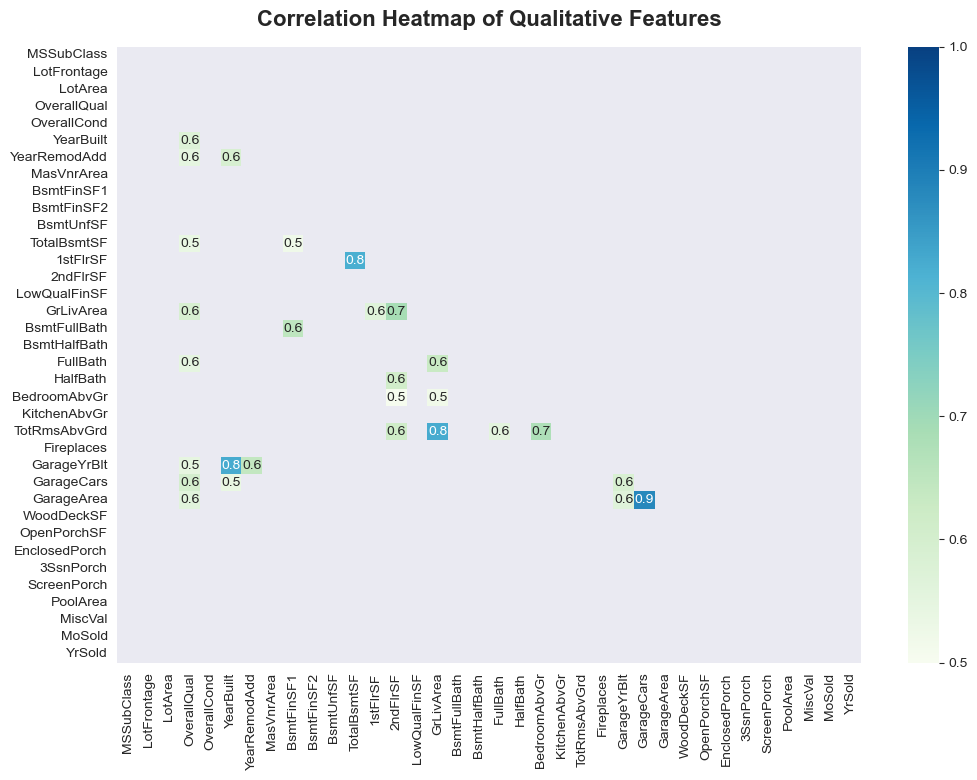

In [29]:
# Create correlation matrix from train data excluding `SalePrice`
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
corr_mat = df_train.iloc[:, :-1].select_dtypes(include=[np.number]).corr()

# Select correlations greater than 0.5
high_corr_mat = corr_mat[abs(corr_mat) >= 0.5]

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(high_corr_mat,mask = np.triu(np.ones_like(high_corr_mat, dtype=bool)),
            annot=True,
            fmt='.1f',
            cmap='GnBu',
            vmin=0.5,
            vmax=1)
plt.title('Correlation Heatmap of Qualitative Features', fontsize=16, fontweight='bold', y=1.02)
plt.grid(False)
plt.show()


Our training data shows evidence of multicollinearity, with several features exhibiting strong correlations with one another.
- GarageCars and GarageArea
- GarageYrBlt and YearBuilt
- 1stFlrSF and TotalBsmtSF
- GrLivArea and TotRmsAbvGrd

Multicollinearity negatively affects prediction models by increasing the standard errors of estimates. To address this, for each pair of highly correlated features,  will remove the one that shows a weaker correlation with `SalePrice`.

#### **2.5. Missing Values**

Most machine learning algorithms cannot be trained directly on datasets containing missing values. That’s why it’s crucial to detect them first and then decide whether to drop the affected features or impute the missing entries.

        Features  missing  total    percent columns_dtype
0         PoolQC     2909   2919  99.657417        object
1    MiscFeature     2814   2919  96.402878        object
2          Alley     2721   2919  93.216855        object
3          Fence     2348   2919  80.438506        object
4     MasVnrType     1766   2919  60.500171        object
5    FireplaceQu     1420   2919  48.646797        object
6    LotFrontage      486   2919  16.649538       float64
7    GarageYrBlt      159   2919   5.447071       float64
8   GarageFinish      159   2919   5.447071        object
9     GarageQual      159   2919   5.447071        object
10    GarageCond      159   2919   5.447071        object
11    GarageType      157   2919   5.378554        object
12  BsmtExposure       82   2919   2.809181        object
13      BsmtCond       82   2919   2.809181        object
14      BsmtQual       81   2919   2.774923        object


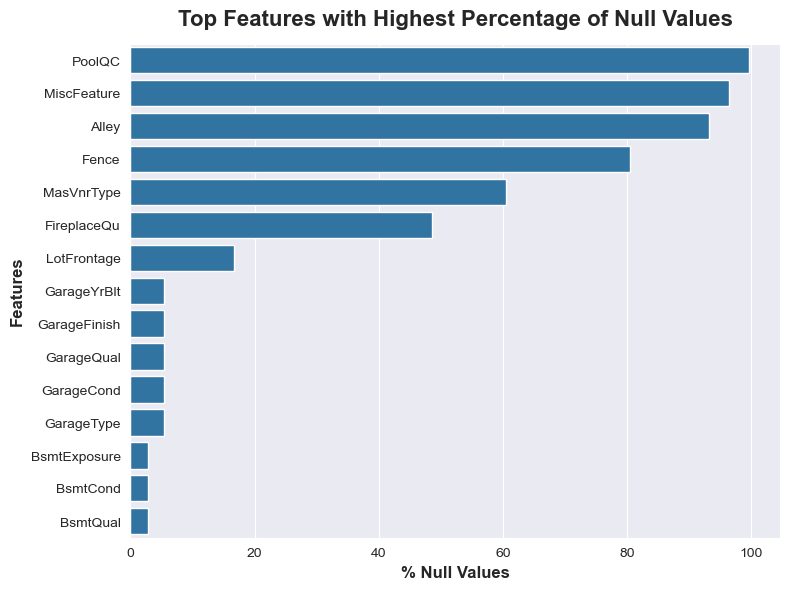

In [30]:
def plot_null_counts(df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame: 
    null_info = df.stb.missing().reset_index().rename({'index':'Features'},axis='columns').sort_values(by='percent',ascending=False)
    null_info['columns_dtype'] = [df[col].dtype for col in null_info['Features']]

    null_info = null_info.loc[null_info['missing']>0].head(top_n)
    print(null_info)

    plt.figure(figsize=(8,6))
    sns.barplot(x='percent', y='Features',data=null_info)
    plt.title('Top Features with Highest Percentage of Null Values', fontsize=16, fontweight='bold', y=1.02)
    plt.xlabel('% Null Values', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return 

plot_null_counts(X)


In [31]:
df_train.stb.missing().query("percent > 0")#.head()

,missing,total,percent
PoolQC,1453,1460,99.520548
MiscFeature,1406,1460,96.301370
Alley,1369,1460,93.767123
Fence,1179,1460,80.753425
MasVnrType,872,1460,59.726027
FireplaceQu,690,1460,47.260274
LotFrontage,259,1460,17.739726
GarageYrBlt,81,1460,5.547945
GarageCond,81,1460,5.547945
GarageType,81,1460,5.547945


In [32]:
# Checking if missing values affect sale price
def missing_value_impact(feature):
    if df_train[feature].isnull().sum() > 0:
        # Get values for homes with and without the features
        has_feature_prices = df_train[~df_train[feature].isnull()]['SalePrice']
        missing_feature_prices = df_train[df_train[feature].isnull()]['SalePrice']

        # Calculate means
        has_feature_mean = has_feature_prices.mean()
        missing_feature_mean = missing_feature_prices.mean()
        
        print(f'{feature}')
        print(f'  Average price with feature: ${has_feature_mean:.2f}')
        print(f'  Average price without feature: ${missing_feature_mean:.2f}')
        print(f'  Difference: ${has_feature_mean - missing_feature_mean:.2f}')
        print(f"  Count with feature: {len(has_feature_prices)}")
        print(f"  Count without feature: {len(missing_feature_prices)}")
        
        # Only run T-test if we have enough data in both groups
        if len(has_feature_prices) > 1 and len(missing_feature_prices) > 1:
            # Run the T-test
            t_stat, p_value = stats.ttest_ind(
                has_feature_prices,
                missing_feature_prices,
                equal_var=False  # Welch's t-test doesn't assume equal variance
            )
            print(f"  T-test: t-statistic = {t_stat:.2f}, p-value = {p_value:.6f}")
        else:
            print("  T-test: Not enough data in both groups for statistical comparison")


# Check for a few features with missing values
for feature in ['LotFrontage', 'BsmtQual', 'Electrical']:
    if df_train[feature].isnull().sum() > 0:
        missing_value_impact(feature)
        print("\n")


LotFrontage
  Average price with feature: $180770.48
  Average price without feature: $181620.07
  Difference: $-849.59
  Count with feature: 1201
  Count without feature: 259
  T-test: t-statistic = -0.20, p-value = 0.844353


BsmtQual
  Average price with feature: $182878.28
  Average price without feature: $105652.89
  Difference: $77225.39
  Count with feature: 1423
  Count without feature: 37
  T-test: t-statistic = 14.70, p-value = 0.000000


Electrical
  Average price with feature: $180930.39
  Average price without feature: $167500.00
  Difference: $13430.39
  Count with feature: 1459
  Count without feature: 1
  T-test: Not enough data in both groups for statistical comparison




#### **2.6. Outlier Analysis**

Lets look at percentage of possible outliers in numerical features.

In [33]:
"""
Calculate the percentage of outliers based on winsorization method for all the numerical features in the DataFrame.

Parameters:
df(pd.DataFrame): The input DataFrame containing numerical features.
lower_percentile(float): The lower percentile foe winsorization. Default is 5.
upper_percentile(float): The upper percentile for winsorization. Default is 95.

Returns:
pd.DataFrame : A DataFrame containing the columns name and percentage of outliers for each numerical features.
"""

#numeric_df = df_train[df_train.columns.difference(['SalePrice'])]
numeric_df = X.select_dtypes(include='number')
outliers_percentages = {}
for col in numeric_df.columns:
    x_low, x_high = np.percentile(numeric_df[col].dropna(),[1,99])
    total_values = len(numeric_df[col])
    outliers = len(numeric_df[~numeric_df[col].between(x_low,x_high)])
    outliers_percentage = round((outliers / total_values)*100 , 2)
    outliers_percentages[col] = outliers_percentage
    
outliers_df = pd.DataFrame(list(outliers_percentages.items()), columns=['Features','Outliers Percentage'])
outliers_data = outliers_df.sort_values(by='Outliers Percentage', ascending=False).reset_index(drop=True)
outliers_data.head(10)



,Features,Outliers Percentage
0,LotFrontage,17.51
1,GarageYrBlt,6.41
2,GrLivArea,2.06
3,1stFlrSF,2.02
4,YearBuilt,1.85
5,MasVnrArea,1.78
6,LotArea,1.68
7,TotRmsAbvGrd,1.54
8,BsmtFinSF1,1.06
9,BsmtFinSF2,1.06


With some basic understandings of the data set and features, let's do data preprocessing and modeling steps.




## **3. Data Preprocessing and Feature Engineering**

#### **3.1 Missing Values Treatment**

In [34]:
missing_df = X.stb.missing()
missing_df['columns_dtype'] = [X[col].dtype for col in missing_df.index]
missing_df['unique_value'] = [X[col].unique() for col in missing_df.index]
missing_df['nunique_value'] = [X[col].nunique() for col in missing_df.index]
missing_df = missing_df.query("percent > 0")
print(f"There are {len(missing_df.index)} features with missing data.\n")
print(missing_df.head(10))

There are 34 features with missing data.

              missing  total    percent columns_dtype  \
PoolQC           2909   2919  99.657417        object   
MiscFeature      2814   2919  96.402878        object   
Alley            2721   2919  93.216855        object   
Fence            2348   2919  80.438506        object   
MasVnrType       1766   2919  60.500171        object   
FireplaceQu      1420   2919  48.646797        object   
LotFrontage       486   2919  16.649538       float64   
GarageYrBlt       159   2919   5.447071       float64   
GarageFinish      159   2919   5.447071        object   
GarageQual        159   2919   5.447071        object   

                                                   unique_value  nunique_value  
PoolQC                                        [nan, Ex, Fa, Gd]              3  
MiscFeature                       [nan, Shed, Gar2, Othr, TenC]              4  
Alley                                         [nan, Grvl, Pave]              2  
Fence 

There are 34 features that have missing values. Will divide them into three groups based on the data description and percentage:

- **Group 1 - Categorical variables where NA means no feature:** 
PoolQC, MiscFeature, Alley, Fence, FireplaceQu, GarageType, GarageFinish, GarageQual, GarageCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, MasVnrType (15 variables)

    For group1, will impute `NA` with `None`.

- **Group 2 - Numerical variables where NA means no feature:**
GarageArea, GarageCars, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, BsmtFullBath, BsmtHalfBath, MasVnrArea, GarageYrBlt (9 variables)

    For group2, will impute `NA` with 0.

- **Group 3 - Other variables:** 
Functional, MSZoning, Electrical, KitchenQual, Exterior1st, Exterior2nd, SaleType, Utilities, LotFrontage, GarageYrBlt (10 variables)

    -  will impute Functional, MSZoning, Electrical, KitchenQual, Exterior1st, Exterior2nd, SaleType, Utilities with their modes,
    - impute LotFrontage with median by neighborhood.
    - impute GarageYrBlt with YearBuilt.



In [35]:
from sklearn.impute import SimpleImputer
X_new = X.copy()
# Group 1:
group_1 = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]
X_new[group_1] = X_new[group_1].fillna("No")

# Group 2:
group_2 = [
    'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

X_new[group_2] = X_new[group_2].fillna(0)

# Group 3:
group_3a = [
    'Functional', 'MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
    'Exterior2nd', 'SaleType', 'Utilities'
]

imputer = SimpleImputer(strategy='most_frequent')
X_new[group_3a] = pd.DataFrame(imputer.fit_transform(X_new[group_3a]), index=X.index)

X_new['LotFrontage'] = X_new.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
X_new.loc[X_new['GarageYrBlt'].isnull(), 'GarageYrBlt'] = X_new.loc[X_new['GarageYrBlt'].isnull(), 'YearBuilt']


In [36]:
# Check whether there is any missing data left:
X_new.isnull().sum().sum()

0

All missing values have been handled.




#### **3.2 Outliers Treatment**

Because regression models are very sensitive to outlier, we need to be aware of them. Let's examine outliers with a scatter plot.



In [31]:
outliers_data.head(10)


,Features,Outliers Percentage
0,LotFrontage,17.51
1,GarageYrBlt,6.41
2,GrLivArea,2.06
3,1stFlrSF,2.02
4,YearBuilt,1.85
5,MasVnrArea,1.78
6,LotArea,1.68
7,TotRmsAbvGrd,1.54
8,BsmtFinSF1,1.06
9,BsmtFinSF2,1.06


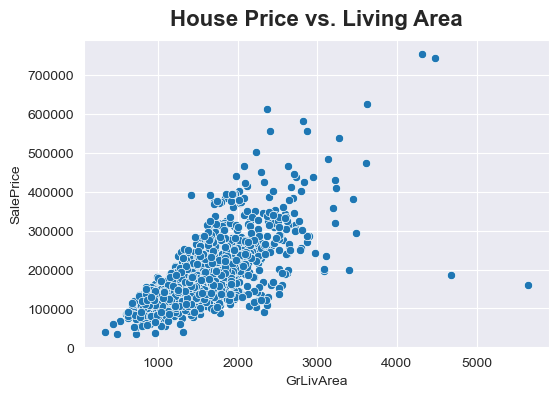

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_train, ax=ax)
ax.set_title('House Price vs. Living Area', fontsize=16, fontweight='bold', y=1.02)
plt.show()


There are two observations lying separately from the rest. They have large living area but low price. They are the outliers that we are looking for. Will delete them from the training set.


In [33]:
outlier_index = df_train[(df_train.GrLivArea > 4000)
                           & (df_train.SalePrice < 200000)].index
X_new.drop(outlier_index, axis="index", inplace=True)
y.drop(outlier_index, axis="index", inplace=True)



#### **3.3. Feature Engineering**



##### **3.3.1. Create New Variables**

In this step I will create new features from weaker features in the training data. For example, the surface area of each floor has low correlation with house price; however, when we sum them up, the relationship becomes much stronger. In fact, __TotalSqFeet becomes the strongest feature in the dataset. The new features I will create are total square feet, total number of bathrooms, age of the house, whether the house was remodeled, and whether the house was sold in the same year it was built.__



In [34]:
X_new['totalSqFeet'] = X_new['TotalBsmtSF'] + X_new['1stFlrSF'] + X_new['2ndFlrSF']
X_new['totalBathroom'] = X_new['FullBath'] + X_new['BsmtFullBath'] + 0.5 * (X_new['HalfBath'] + X_new['BsmtHalfBath'])
X_new['houseAge'] = X_new['YrSold'] - X_new['YearBuilt']
X_new['reModeled'] = np.where(X_new['YearRemodAdd'] == X_new['YearBuilt'], 0, 1).astype('bool')
X_new['isNew'] = np.where(X_new['YrSold'] == X_new['YearBuilt'], 1, 0).astype('bool')



In [35]:
X_new.dtypes.value_counts()

object     43
int64      26
float64    13
bool        2
Name: count, dtype: int64

##### **3.3.2. Label Encoding**

Ordinal categorical features are label encoded.



In [36]:
from sklearn.preprocessing import LabelEncoder

# Ordinal categorical columns
for col in ordinal_qual_cond_var:
    qual_map = {'No': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
    X_new[col+"Numeric"] = X_new[col].map(lambda x: qual_map.get(x, 0))  # Map to numeric, default to 0 for 'No' or missing

# for ordinal features based on basement and finish types
X_new['BsmtExposureNumeric'] = X_new['BsmtExposure'].map({'No': 0, 'Mn': 1, 'Av': 3, 'Gd': 4})
X_new['BsmtFinType1Numeric'] = X_new['BsmtFinType1'].map({'No': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
X_new['BsmtFinType2Numeric'] = X_new['BsmtFinType2'].map({'No': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
X_new['GarageFinishNumeric'] = X_new['GarageFinish'].map({"No":0, "Unf":1, "RFn":2, "Fin":3})

# For ordinal features based on functional and utility
X_new['LotShapeNumeric'] = X_new['LotShape'].map({"IR3" : 1, "IR2" : 2, "IR1" : 3, "Reg" : 4})
X_new['FenceNumeric'] = X_new['Fence'].map({"No":0, "MnWw":1, "GdWo":2, "MnPrv":3, "GdPrv":4})
X_new['FunctionalNumeric'] = X_new['Functional'].map({"Sal":1, "Sev":2, "Maj2":3, "Maj1":4, "Mod":5, "Min2":6, "Min1":7, "Typ":8})
X_new['UtilitiesNumeric'] = X_new['Utilities'].map({"ELO":1, "NoSeWa":2, "NoSewr":3, "AllPub":4})


In [37]:
df = pd.concat([X_new,y], axis="columns")
df.head()
df.stb.missing().query("missing > 0")

,missing,total,percent
SalePrice,1459,2917,50.017141


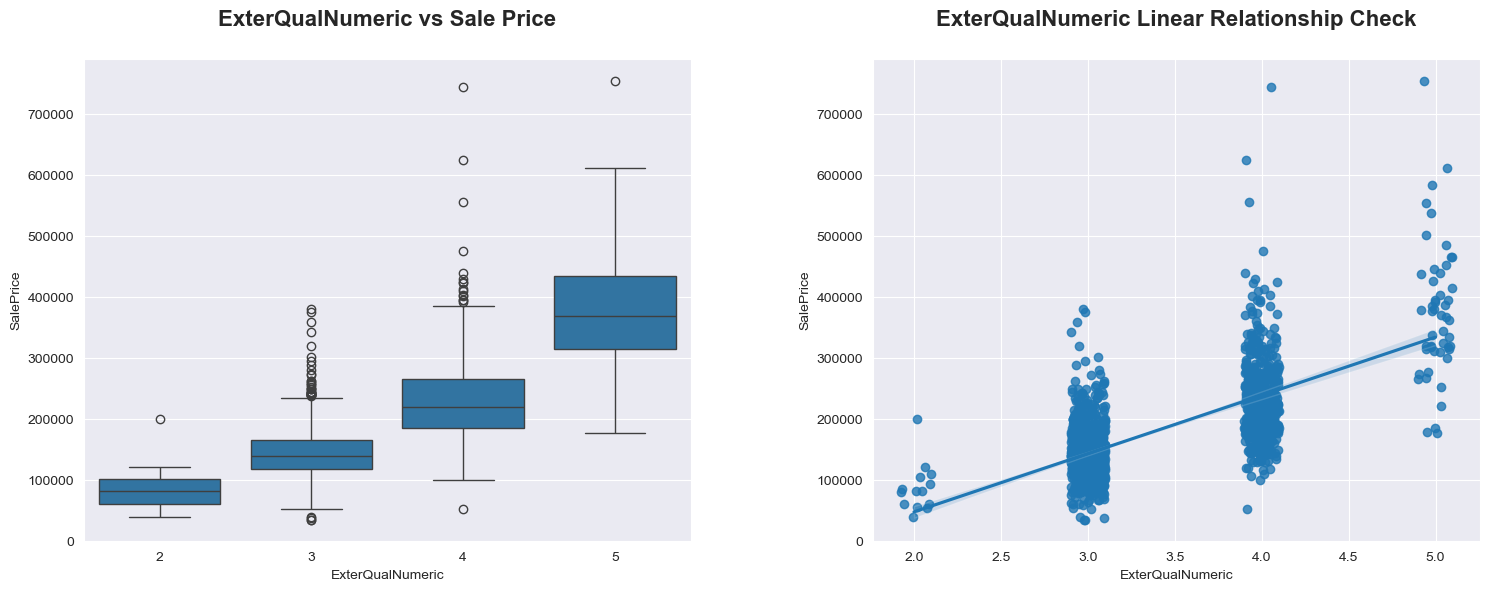

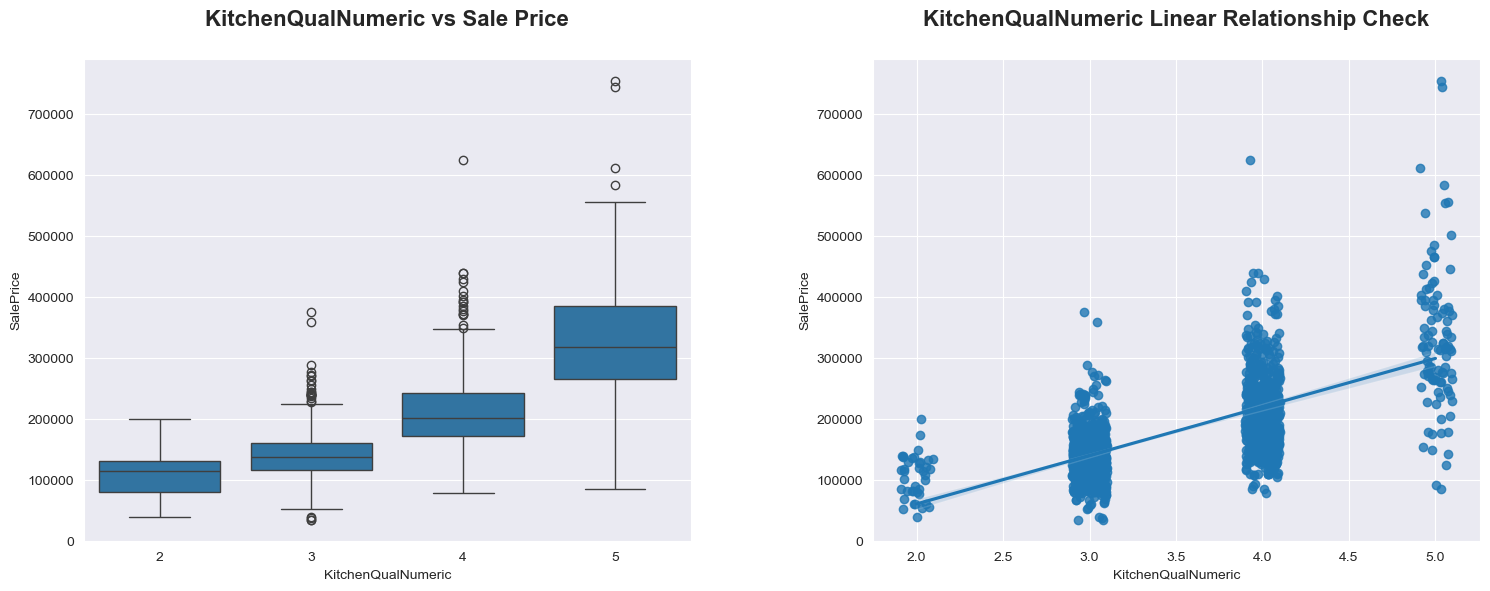

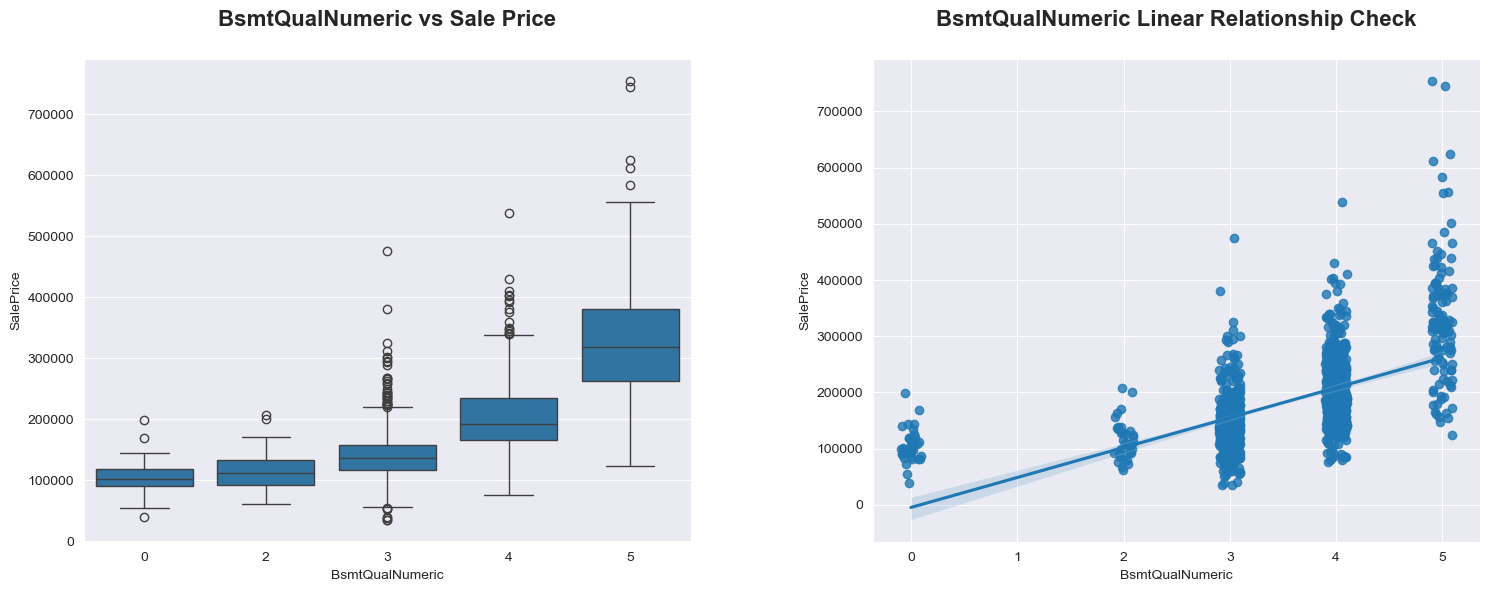

In [38]:
# Visualizing some distributions of the new features with respect to SalePrice
for feature in ['ExterQualNumeric', 'KitchenQualNumeric', 'BsmtQualNumeric']:
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Boxplot
    sns.boxplot(x=feature, y='SalePrice', data=df[~df['SalePrice'].isnull()], ax=ax[0])
    ax[0].set_title(f'{feature} vs Sale Price', fontsize=16, fontweight='bold', y=1.05)

    # Regression plot
    sns.regplot(x=feature, y='SalePrice', data=df[~df['SalePrice'].isnull()], x_jitter=0.1, ax=ax[1])
    ax[1].set_title(f'{feature} Linear Relationship Check', fontsize=16, fontweight='bold', y=1.05)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()


**Key Findings:**

- **Ordinal encoding effect:** Transforming these ordinal categories into numbers reveals a clear upward trend — higher quality scores correspond to higher sale prices in a near‑linear fashion.



##### **3.3.3. Transform Numerical Variables to Categorical Variables**

Because I have calculated age of houses, YearBuilt is no longer needed. However, YrSold could have a large impact on house price (e.g. In economic crisis years, house price could be lower). Therefore, I will transform it into categorical variables.

Like YrSold, some numerical variables don't have any ordinal meaning (e.g. MoSold, MSSubClass). I will transform them into categorical variables.


In [39]:
to_factor_cols = ['YrSold', 'MoSold', 'MSSubClass']

for col in to_factor_cols:
    X_new[col] = X_new[col].apply(str)



##### **3.4. Non-Linear Relationship : OverallQual and SalePrice**

Correlations:
Original correlation: 0.7957742674249434
Squared term correlation: 0.8245819400747855




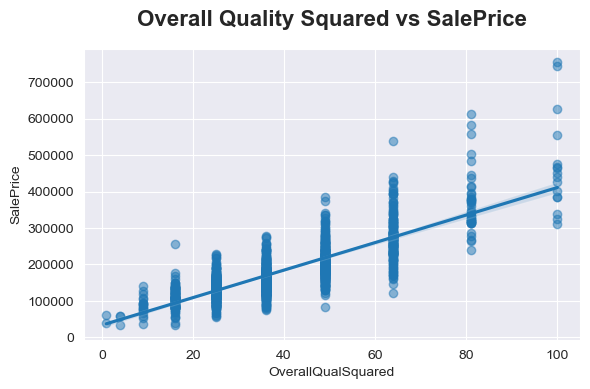

Key Insights:
- OverallQual shows stronger effect at the end(suggesting non-linear relationship by squared term)


In [40]:
# Analysis of squared terms for non-linear relationships
df['OverallQualSquared'] = df['OverallQual']**2

print("Correlations:")
print('Original correlation:', df.loc[~df['SalePrice'].isnull(), 'OverallQual'].corr(df.loc[~df['SalePrice'].isnull(), 'SalePrice']))
print('Squared term correlation:', df.loc[~df['SalePrice'].isnull(), 'OverallQualSquared'].corr(df.loc[~df['SalePrice'].isnull(), 'SalePrice']))
print("\n")

plt.figure(figsize=(6,4))
sns.regplot(x='OverallQualSquared', y='SalePrice', data=df[~df['SalePrice'].isnull()], scatter_kws={'alpha':0.5})
plt.title('Overall Quality Squared vs SalePrice', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("Key Insights:")
print("- OverallQual shows stronger effect at the end(suggesting non-linear relationship by squared term)")


##### **3.5. Feature Interaction --- Multiplying Features**

**3.5.1. Quality Size = OverallQual x GrLivArea** 

How does the relationship between house quality (OverallQual) and house size (GrLivArea) jointly influence the sale price in the Ames Housing dataset?

Original Overall Qual correlation: 0.7957742674249434
Original Gr Liv Area correlation: 0.7349681645359327
Original Overall Cond correlation: -0.07794845990302275
Quality × Area interaction correlation: 0.8741160990972617
Quality × Condition interaction correlation: 0.5667589098263816


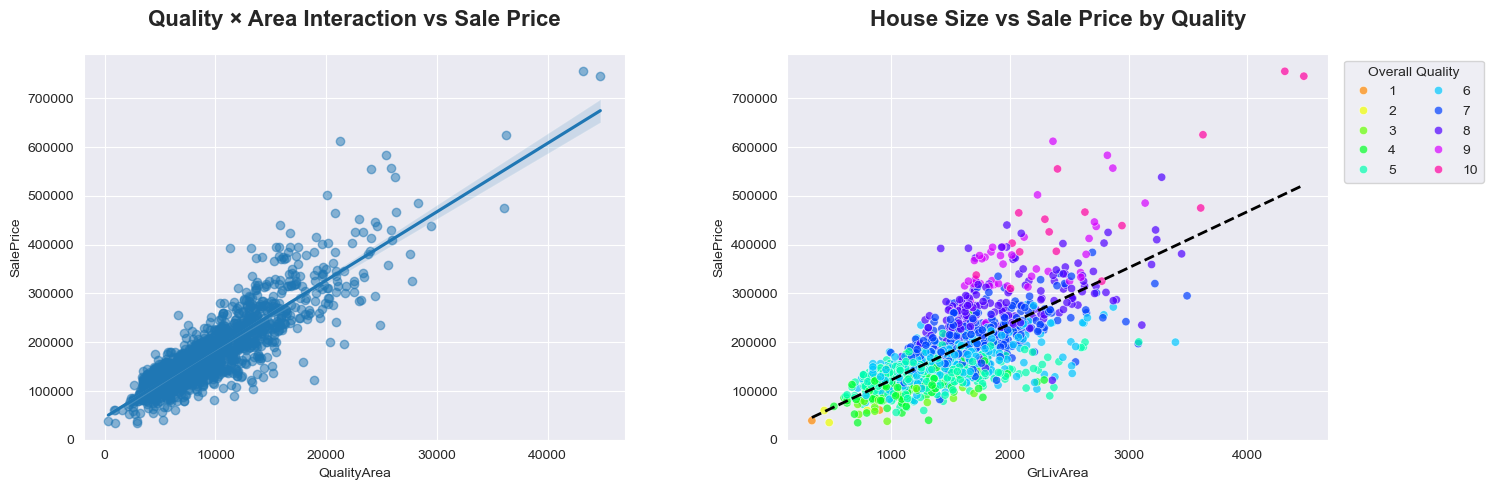

In [41]:
df_new = df[~df['SalePrice'].isnull()].copy()

df_new.loc[:, 'QualityArea'] = df_new['OverallQual'] * df_new['GrLivArea']
df_new.loc[:, 'QualityCond'] = df_new['OverallQual'] * df_new['OverallCond']

# Checking improvements in correlation
print("Original Overall Qual correlation:", df_new['OverallQual'].corr(df_new['SalePrice']))
print("Original Gr Liv Area correlation:", df_new['GrLivArea'].corr(df_new['SalePrice']))
print("Original Overall Cond correlation:", df_new['OverallCond'].corr(df_new['SalePrice']))
print("Quality × Area interaction correlation:", df_new['QualityArea'].corr(df_new['SalePrice']))
print("Quality × Condition interaction correlation:", df_new['QualityCond'].corr(df_new['SalePrice']))

# Visualize interactions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Linear relationship
sns.regplot(x='QualityArea', y='SalePrice', data=df_new, scatter_kws={'alpha':0.5}, ax=ax[0])
ax[0].set_title('Quality × Area Interaction vs Sale Price', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)

# relationship of house size and house price affected by quality
sns.scatterplot(x='GrLivArea', y='SalePrice', hue='OverallQual', data=df_new, hue_order=range(1, 11), palette=sns.color_palette('hsv', n_colors = len(df_new['OverallQual'].unique())), alpha=0.7, ax=ax[1])
ax[1].set_title('House Size vs Sale Price by Quality', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax[1].legend(title='Overall Quality', bbox_to_anchor=(1.3, 1), loc='upper right', ncol=2)

# Linear relationship house size and house price
sns.regplot(x='GrLivArea', y='SalePrice', data=df_new, scatter=False, ci=False, color='k', line_kws={'lw':2, 'ls':'--'}, ax=ax[1])


plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()



**Insight : Quality × House Size Interaction significant (high-quality, large home size command high premium)**

**3.5.2. Overall Quality vs SalePrice by Neighborhoods**

How does the relationship between overall house quality (OverallQual) and sale price vary across different neighborhoods in Ames?

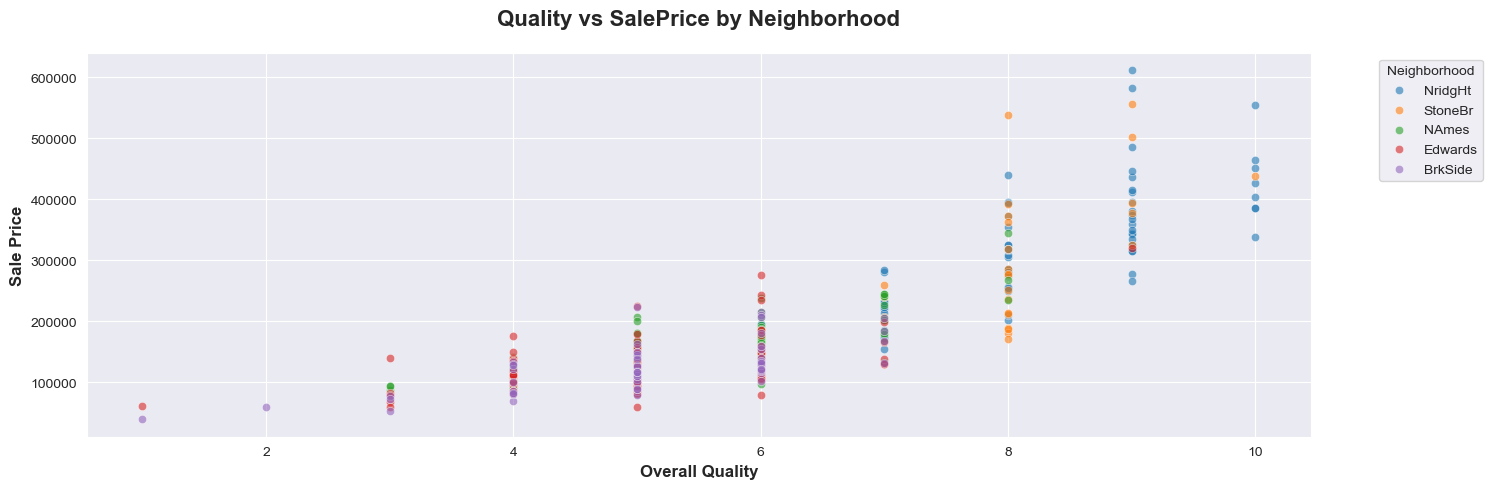

In [42]:
plt.figure(figsize=(15, 5))
neighborhoods = ['NridgHt', 'StoneBr', 'NAmes', 'Edwards', 'BrkSide']  # select some neighborhoods
for neighborhood in neighborhoods:
    subset = df_new[df_new['Neighborhood'] == neighborhood]
    sns.scatterplot(x='OverallQual', y='SalePrice', data=subset, alpha=0.6, label=neighborhood)

plt.xlabel('Overall Quality', fontsize=12, fontweight='bold')
plt.ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.title('Quality vs SalePrice by Neighborhood', fontsize=16, fontweight='bold', y=1.05)
plt.legend(title='Neighborhood', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Insight: Quality x Neighborhood interaction reveals that the value of quality differs across locations and some neighborhoods have higher price premiums for quality than others.**

**3.5.3. Age Condition = House Age x Overall Condition**

How does the interaction between age and condition influence buyer perception of value

House Age correlation: -0.5240670055640873
Overall Condition correlation: -0.07794845990302275
Age × Condition interaction correlation: -0.42575615052366883


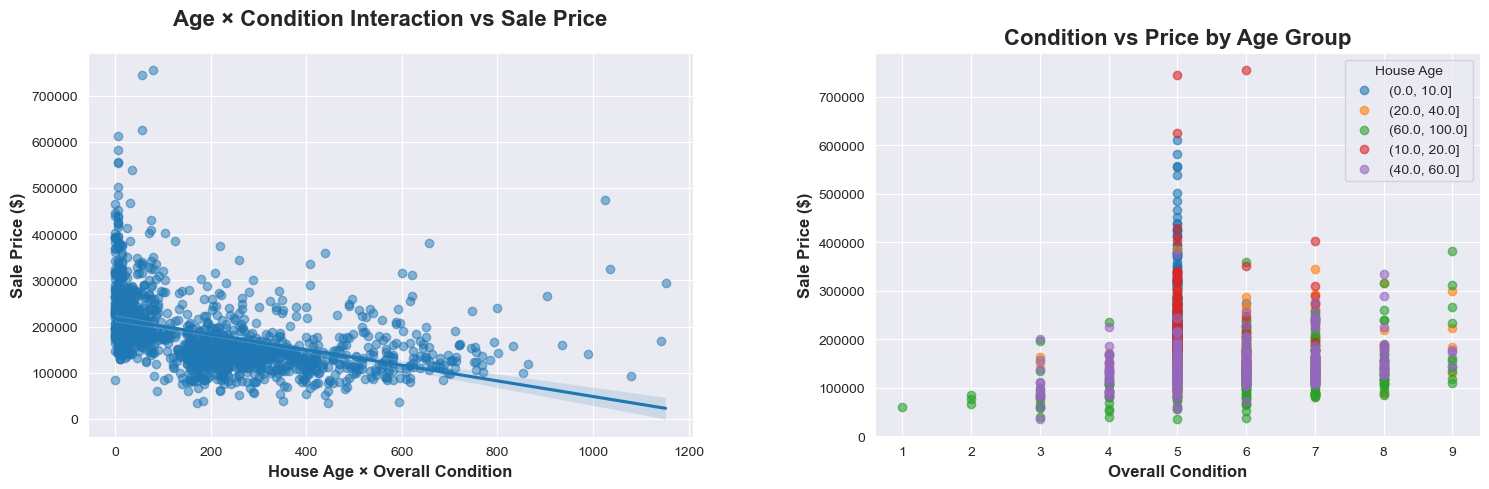

In [43]:
df_new.loc[:, 'HouseAge'] = df_new['YrSold'] - df_new['YearBuilt']
df_new.loc[:, 'AgeCondition'] = df_new['HouseAge'] * df_new['OverallCond']

# Check how this interaction correlates with price compared to individual components
print("House Age correlation:", df_new['HouseAge'].corr(df_new['SalePrice']))
print("Overall Condition correlation:", df_new['OverallCond'].corr(df_new['SalePrice']))
print("Age × Condition interaction correlation:", df_new['AgeCondition'].corr(df_new['SalePrice']))

# Visualize the Age × Condition interaction
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(x='AgeCondition', y='SalePrice', data=df_new, scatter_kws={'alpha':0.5}, ax=ax[0])
ax[0].set_title('Age × Condition Interaction vs Sale Price', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax[0].set_xlabel('House Age × Overall Condition', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Sale Price ($)', fontsize=12, fontweight='bold')


# Check how this interaction works across different age groups
age_bins = [0, 10, 20, 40, 60, 100]
df_new['AgeGroup'] = pd.cut(df_new['HouseAge'], bins=age_bins)

for age_group in df_new['AgeGroup'].unique():
    subset = df_new[df_new['AgeGroup'] == age_group]
    if len(subset) > 10:  # Only plot if enough data points
        ax[1].scatter(subset['OverallCond'], subset['SalePrice'], alpha=0.6, label=str(age_group))
    
ax[1].set_xlabel('Overall Condition', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Sale Price ($)', fontsize=12, fontweight='bold')
ax[1].set_title('Condition vs Price by Age Group', fontsize=16, fontweight='bold')
ax[1].legend(title='House Age', fontsize=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**Insight:**

- The AgeCondition feature (House Age × Overall Condition) captures how maintenance interacts with age, showing that well-kept older homes retain value better while poor condition accelerates depreciation.

- The Age × Condition interaction indicates that newer homes in better condition command higher values.

---

##### __3.6. Skewness and Normalizing Variables__

Normal distribution is one of the assumption that linear regression relies on. Therefore, transfoming skewed data will help our models perform better.

First, let's examine the target variable `SalePrice` with Distribution plot and Quantile-Quantile plot.

__Target variable__



In [44]:
from scipy.stats import norm

def normality_plot(X):
    """
    1. Draw distribution plot with normal distribution fitted curve
    2. Draw Quantile-Quantile plot 
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram with KDE
    sns.histplot(X, kde=True, stat="density", ax=axes[0])
    
    # Fit a normal distribution curve
    mu, sigma = norm.fit(X)
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    axes[0].plot(x, p, 'r--', linewidth=2)
    axes[0].set_title(f'Distribution Plot {X.name}', fontsize=16, fontweight='bold', y=1.02)

    # Q-Q plot
    stats.probplot(X, plot=axes[1])
    axes[1].set_title(f'Q-Q Plot {X.name}', fontsize=16, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()



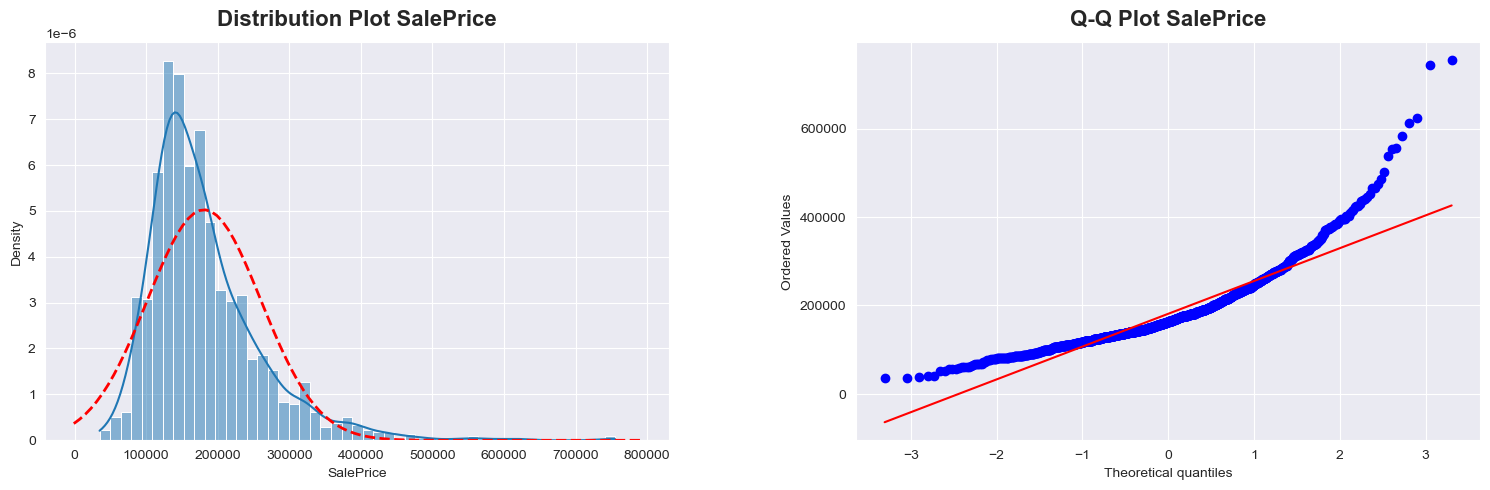

In [45]:
normality_plot(y);



In [46]:
from scipy.stats import norm

def normality_plot(X):
    """
    1. Draw distribution plot with normal distribution fitted curve
    2. Draw Quantile-Quantile plot 
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram with KDE
    sns.histplot(X, kde=True, stat="density", ax=axes[0])
    
    # Fit a normal distribution curve
    mu, sigma = norm.fit(X)
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    axes[0].plot(x, p, 'r--', linewidth=2)
    axes[0].set_title(f'Distribution Plot {X.name}', fontsize=16, fontweight='bold', y=1.02)

    # Q-Q plot
    stats.probplot(X, plot=axes[1])
    axes[1].set_title(f'Q-Q Plot {X.name}', fontsize=16, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()



One of the methods to normalize right-skewed data is using log transformation because big values will be pulled to the center. However, log(0) is Nan, so I will use log(1+X) to fix skewness instead.



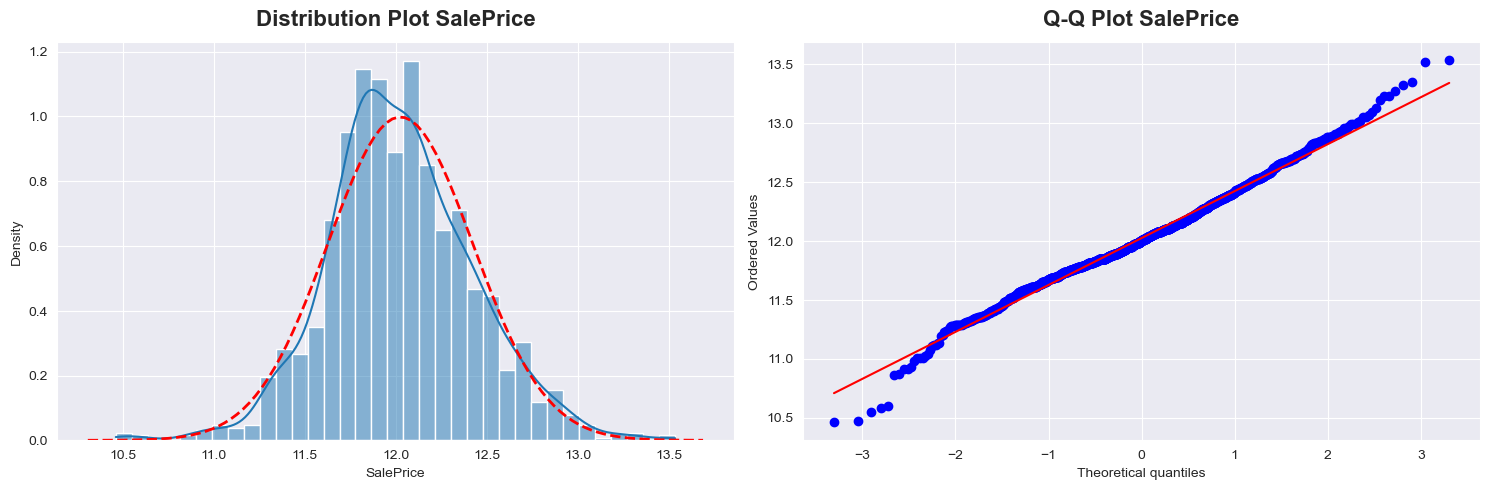

In [47]:
y_new = np.log(1 + y) 
normality_plot(y_new);


And this is `SalePrice` after log transformation. The sknewness has been fixed.



In the next step, I will examine skewness in the rest of numerical features and use transformation to fix them.



__Fixing skewness in other numerical variables__

If skewness is less than -1 or greater than 1, the distribution is __highly skewed__.

If skewness is between -1 and -0.5 or between 0.5 and 1, the distribution is __moderately skewed__.

If skewness is between -0.5 and 0.5, the distribution is __approximately symmetric__.

Below are skewed features in our original train data.



In [48]:
skewness = df_new[num_cols].skew().sort_values(ascending=False)
skewness[abs(skewness) > 0.75]


MiscVal          24.460085
PoolArea         15.948945
LotArea          12.573925
3SsnPorch        10.297106
LowQualFinSF      9.004955
KitchenAbvGr      4.484883
BsmtFinSF2        4.251925
ScreenPorch       4.118929
BsmtHalfBath      4.100114
EnclosedPorch     3.087164
MasVnrArea        2.696329
OpenPorchSF       2.339829
LotFrontage       1.548376
WoodDeckSF        1.545805
MSSubClass        1.407011
GrLivArea         1.010992
BsmtUnfSF         0.920903
1stFlrSF          0.887637
2ndFlrSF          0.812957
BsmtFinSF1        0.764789
dtype: float64

Let's check normality of GrLivArea:



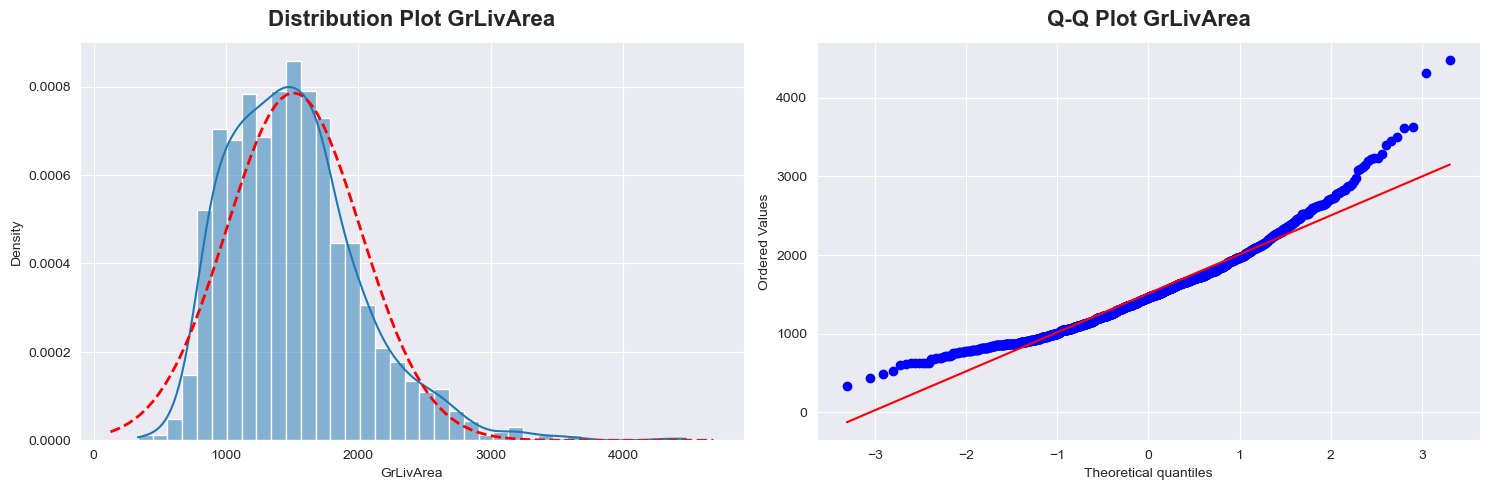

In [49]:
normality_plot(df_new['GrLivArea'])


In [50]:
# List of skewed columns
skewed_cols = list(skewness[abs(skewness) > 0.5].index)

# Remove 'MSSubClass' and 'SalePrice'
skewed_cols = [
    col for col in skewed_cols if col not in ['MSSubClass', 'SalePrice']
]

# Log-transform skewed columns
for col in skewed_cols:
    X_new[col] = np.log(1 + X_new[col])


Below is normality of GrLivArea after log-transformation. Skewness has been fixed.



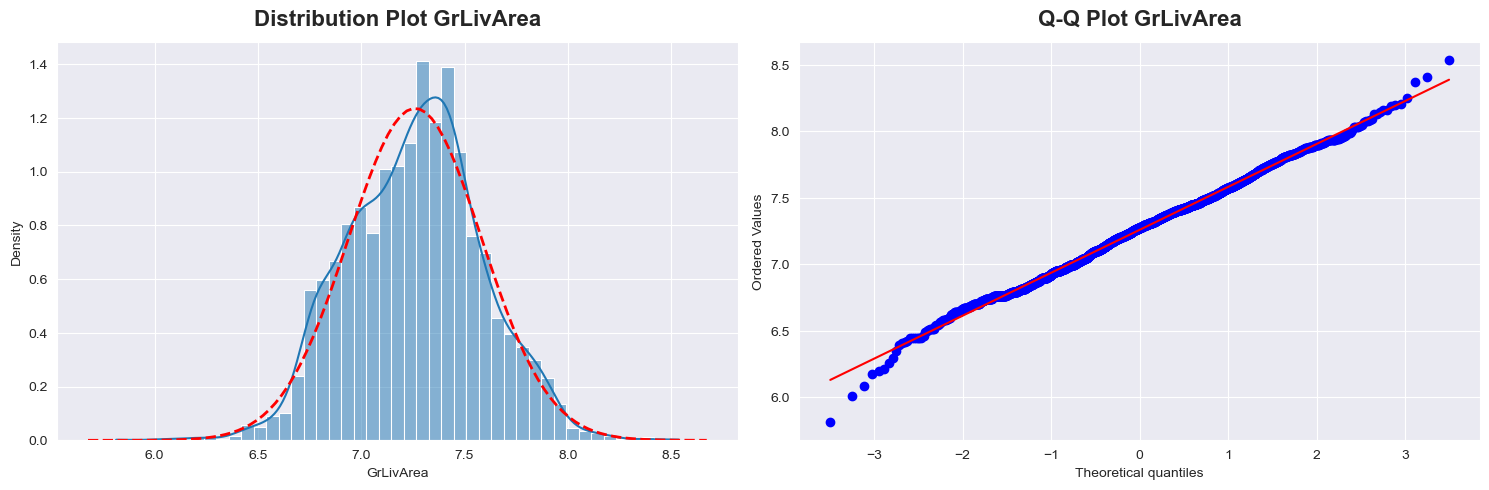

In [51]:
normality_plot(X_new['GrLivArea']);


---
## **4. Data Preprocessing**

In [54]:
def clean_data(df):
    result = df.copy()
    result.columns = result.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

    # Handle missing values
    """Group 1: Categorical features where missing value likely means absence of the feature, so we fill with 'No'.
    Group 2: Numerical features where missing value likely means zero, so we fill with 0.
    Group 3: Categorical features where we fill missing values with the most frequent category and
    for 'LotFrontage' we fill missing values with the median of the neighborhood, and for 'GarageYrBlt' we fill missing values with 'YearBuilt'."""
    
    group_1 = [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
        'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
        'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
    ]
    result[group_1] = result[group_1].fillna("No")

    group_2 = [
        'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
        'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
    ]
    result[group_2] = result[group_2].fillna(0)

    group_3a = [
        'Functional', 'MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
        'Exterior2nd', 'SaleType', 'Utilities'
    ]
    imputer = SimpleImputer(strategy='most_frequent')
    result[group_3a] = pd.DataFrame(imputer.fit_transform(result[group_3a]), index=result.index)

    result['LotFrontage'] = result.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
    result.loc[result['GarageYrBlt'].isnull(), 'GarageYrBlt'] = result.loc[result['GarageYrBlt'].isnull(), 'YearBuilt']

    return result

# Apply the cleaning function to the dataset
print("="*20, "Data Cleaning", "="*20)
train_cleaned = clean_data(train_df)
test_cleaned = clean_data(test_df)

==================== Data Cleaning ====================


In [57]:
# Checking if cleaning worked
train_missing_after = train_cleaned.isnull().sum().sum()
test_missing_after = test_cleaned.isnull().sum().sum()

print("="*20, "Missing Values After Cleaning", "="*20)
if train_missing_after == 0:
    print("No missing values in training data after cleaning.")
else:
    print(f"Total missing values in training data after cleaning: {train_missing_after}")

if test_missing_after == 0:
    print("No missing values in testing data after cleaning.")
else:
    print(f"Total missing values in testing data after cleaning: {test_missing_after}")



==================== Missing Values After Cleaning ====================
No missing values in training data after cleaning.
No missing values in testing data after cleaning.


In [58]:
# Saving cleaned datasets for next notebook

parent_path = Path.cwd().parent
train_cleaned.to_csv(parent_path.joinpath("data", "processed", "train_cleaned.csv"), index=False)
test_cleaned.to_csv(parent_path.joinpath("data", "processed", "test_cleaned.csv"), index=False)
print("="*20, "Cleaned datasets saved successfully.", "="*20)


==================== Cleaned datasets saved successfully. ====================


## **4. Modelling**

##### **4.1. Split the data**

In [47]:
df_train.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [48]:
ntest = len(df_test)
X_train = X_new.iloc[:-ntest, :]
X_test = X_new.iloc[-ntest:, :]
y_train = np.log1p(y) # log(1 +y) transform
print("X_train.shape:", X_train.shape)
print("X_test.shape:", X_test.shape)
print("y_train.shape:", y.shape)


X_train.shape: (1458, 84)
X_test.shape: (1459, 84)
y_train.shape: (1458,)


##### **4.1.2. Feature Scaling**

Except for Decision Tree and Random Forest, it is highly recommended to standardize the data set before running machine learning algorithms since optimization methods and gradient descent run and converge faster on similarly scaled features.

However, outliers can often influence the sample mean and standard deviation in a negative way, and models like Lasso and Elastic Net are very sensitive to outliers. In such cases, the median and the interquartile range often give better results. I will use `RobustScaler` to transform the training data.

##### **4.1.3. One Hot Encoding**

Machine learning models take numeric values to predict, will use one-hot-encoding for categorical features.

##### **4.1.4. Convert bool to integers**

Convert bool to integers using FunctionTransformer

In [49]:
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Identify features by type
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(include='object').columns
bool_cols = X_train.select_dtypes(include='bool').columns

# Transformes to cast boolean to int
bool_to_int = FunctionTransformer(lambda x: x.astype(int))

# Define preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bool", bool_to_int, bool_cols)
    ]
)

# build pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

**4.2. Cross-Vaildation**

During model evaluation, it is standard practice to divide the training dataset into two subsets: training and testing. However, a model that performs well on one particular test set may still fail to generalize, showing poor results when applied to other unseen data.

`Cross-validation` helps check how well a model will perform on new data. In k-fold cross-validation, the training data is split into 5 parts. The model is trained on 4 parts and tested on the remaining part. This is repeated for all folds, and the final score is the average of the results.

Will write a function to calculate the **Root Mean Squared Logarithmic Error (RMSLE)** using cross-validation. Since the target variable has been transformed to log(1 + y), the __Mean Squared Error__ on this transformed target directly corresponds to the __Mean Squared Logarithmic Error__ for the original `SalePrice`.

In [50]:
from sklearn.model_selection import KFold, cross_val_score
# Cross-validation RMSLE function:
n_folds = 5

def getRMSLE(model, X, y):
    """ 
    Compute Root Mean Squared Logarithmic Error (RMSLE) using cross-validation.

    Parameters:
    model: The machine learning model to evaluate.
        X: The feature dataset.
        y: The target variable.
    Returns:
    float: The average RMSLE across all folds of training data.
    since y is log(1 + SalePrice), MSE is calculated on log-scale and it corresponds to MSLE on SalePrice.
    """
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kf))
    return rmse.mean()



##### **4.2.1. Linear Regression**

In [ ]:
# Evaluate pipeline
score = getRMSLE(pipeline, X_train, y_train)
print("Cross-validated RMSLE:", score)

Cross-validated RMSLE: 0.13331502613441965


: 

##### **4.3. Regularized Linear Regression**

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

: 

##### **4.3.1. Ridge Regression**

In the regularized linear regression (Ridge), we try to minimize:

$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2 + \frac{\alpha}{2m}\sum_{j=1}^{n}\theta_j^2$

where  ${\alpha}$
is a regularization parameter which controls the degree of regularization (thus, help preventing overfitting). The regularization term puts a penalty on the overall cost J. As the magnitudes of the model parameters ${\theta_j}$
increase, the penalty increases as well.

I will find the ${\alpha}$
that gives me the smallest RMSLE from cross-validation:

In [ ]:
# Define pipeline with Ridge
pipeline_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(random_state=42))
])

# Candidate lambda (alpha) values
alpha_list = list(np.linspace(20, 25, 101))

# Loop through values and evaluate with your RMSLE function
results = {}
for lam in alpha_list:
    pipeline_ridge.set_params(regressor__alpha=float(lam))
    score = float(getRMSLE(pipeline_ridge, X_train, y_train))
    results[(float(lam))] = score

# Find best lambda
best_alpha = min(results, key=results.get)
print("Best α (alpha):", best_alpha)
print("Best RMSLE:", results[best_alpha])


Best α (alpha): 24.05
Best RMSLE: 0.1133751925148335


: 

In [ ]:
# Record best RMSLE for all models
best_rmsle = {}
best_rmsle['Ridge'] = results[best_alpha]

: 

In [ ]:
ridge = Ridge(alpha=24.05, random_state=42)

: 

In [ ]:
# Visualization of RMSLE by alpha using ridge regression
alpha_list = list(np.linspace(20, 25, 101))

rmsle_ridge = {}
for alpha_ in alpha_list:
    pipeline_ridge.set_params(regressor__alpha=float(alpha_))   # set alpha for Ridge
    score = float(getRMSLE(pipeline_ridge, X_train, y_train))
    rmsle_ridge[float(alpha_)] = score



: 

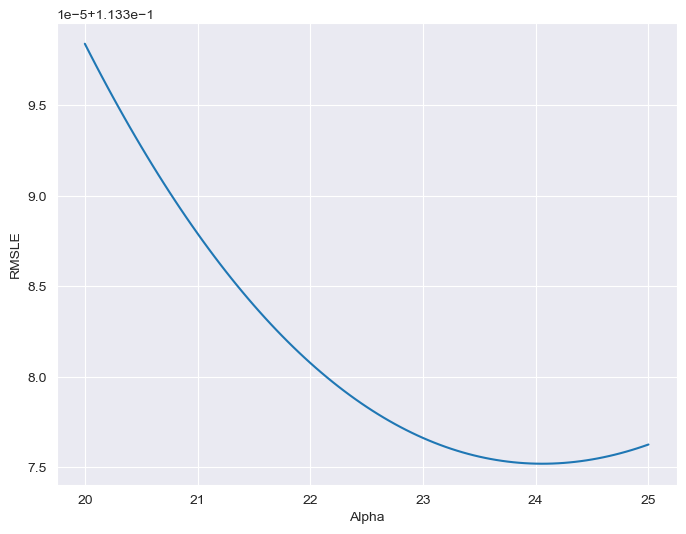

: 

In [ ]:

ridge_alphas = [alpha for alpha in rmsle_ridge.keys()]
ridge_scores = [score for score in rmsle_ridge.values()]

plt.figure(figsize=(8, 6))
plt.plot(ridge_alphas, ridge_scores);
plt.xlabel("Alpha")
plt.ylabel("RMSLE")
plt.grid(True)
plt.show()


##### **4.3.2. Lasso Regression**

Lasso Regression is very similar to Ridge regression. One difference is that in the regularization term, instead of using sum of squared of ${\theta}$, we use sum of absolute value of  $\theta$:

$J(\theta)=\frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)})-y^{(i)})^2+\frac{\alpha}{2m}\sum_{j=1}^{n}|\theta_j|$

Another big difference is that Ridge Regresion can only shrink parameters close to zero while Lasso Regression can shrink some parameters all the way to 0. Therefore, we can use Lasso Regression to perform feature selection and regression.



In [ ]:
pipeline_lasso = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Lasso(max_iter=10000, random_state=42)) # Ensure enough iterrations
])

alpha_list = list(np.linspace(0.0006, 0.0007, 11))

# Loop through values and evaluate with your RMSLE function
lasso_results = {}
for alpha in alpha_list:
    pipeline_lasso.set_params(regressor__alpha=float(alpha))
    score = float(getRMSLE(pipeline_lasso, X_train, y_train))
    lasso_results[(float(alpha))] = score

# Find best alpha
best_alpha_lasso = min(lasso_results, key=lasso_results.get)
print("Best α (alpha) for Lasso:", best_alpha_lasso)
print("Best RMSLE for Lasso:", lasso_results[best_alpha_lasso])


Best α (alpha) for Lasso: 0.0006
Best RMSLE for Lasso: 0.11149118722673948


: 

In [ ]:
best_rmsle['Lasso'] = lasso_results[best_alpha_lasso]
lasso = Lasso(alpha=0.0006, max_iter=10000, random_state=42)

: 

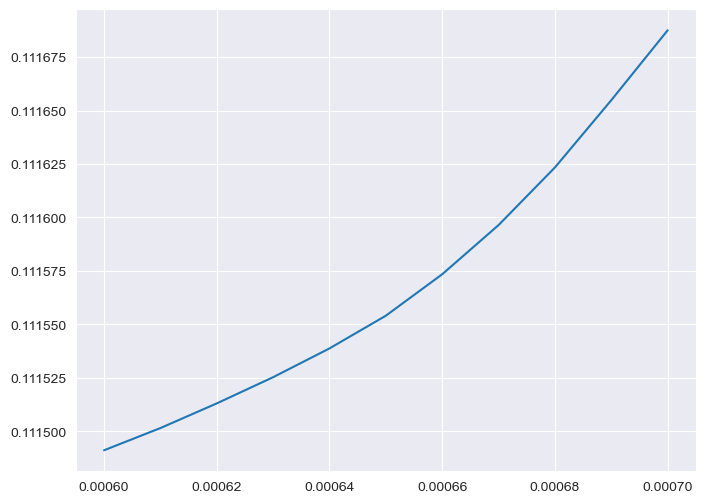

: 

In [ ]:
lasso_alphas = [alpha for alpha in lasso_results.keys()]
lasso_scores = [score for score in lasso_results.values()]
plt.figure(figsize=(8, 6))
plt.plot(lasso_alphas, lasso_scores);

##### **4.3.3. Elastic Net**

In [ ]:
from sklearn.linear_model import ElasticNet
pipeline_enet = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", ElasticNet(max_iter=10000, random_state=42))
])
# Cross validation set up
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# parameters to tune(penality = lambda, l1_ratio=mixture(alpha))
lam_values = np.logspace(-3, -2, 40)
mixture_ = [0, 0.05, 0.1, 0.15]

param_grid = {
    "regressor__alpha":lam_values,
    "regressor__l1_ratio": mixture_
}

# Grid search with cross-validation
from sklearn.model_selection import GridSearchCV

grid_search_enet = GridSearchCV(
    estimator=pipeline_enet,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=1
)

# Fit the model
grid_search_enet.fit(X_train, y_train)


# Best parameters and score
print("Best Parameters for ElasticNet:", grid_search_enet.best_params_)
print("Best RMSE Grid Search Score:", np.sqrt(-grid_search_enet.best_score_))



c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.021e+00, tolerance: 1.836e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.117e+00, tolerance: 1.887e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in

Best Parameters for ElasticNet: {'regressor__alpha': 0.00307029062975785, 'regressor__l1_ratio': 0.15}
Best RMSE Grid Search Score: 0.11233268409568856


: 

In [ ]:
# Evaluate RMSLE

best_pipeline_enet = grid_search_enet.best_estimator_
#clean_params = {k.replace("regressor__", ""): v for k, v in best_pipeline_enet.items()}
best_enet_score = getRMSLE(best_pipeline_enet, X_train, y_train)
print("Best Cross Validated ElasticNet RMSLE:", best_enet_score)


Best Cross Validated ElasticNet RMSLE: 0.1120562664103772


: 

In [ ]:
best_rmsle['ElasticNet'] = best_enet_score
enet_best = ElasticNet(alpha=0.00307029062975785, l1_ratio=0.15, max_iter=10000, random_state=42)

: 

##### **4.3.4. Xgboost**

In [69]:
from xgboost import XGBRegressor

pipeline_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(objective="reg:squarederror",random_state=42))
])

#----params grid------
params_grid = {
    "regressor__n_estimators": [500, 1000],
    "regressor__max_depth": [1, 2],
    "regressor__min_child_weight": [1, 2],
    "regressor__gamma": [0, 0.1],
    "regressor__subsample": [0.6, 0.7],
    "regressor__colsample_bytree": [0.4, 0.5],
    "regressor__reg_alpha": [0.1, 0.4],
    "regressor__reg_lambda": [0.4, 0.6],
    "regressor__learning_rate": [0.01, 0.05],
    "regressor__scale_pos_weight": [1]
}

# GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb, param_grid=params_grid,
    scoring="neg_mean_squared_error", cv=5, n_jobs=-1, verbose=2
)
grid_search_xgb.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search_xgb.best_params_)
print("Best RMSLE from GridSearchCV:", np.sqrt(-grid_search_xgb.best_score_))



OSError: [Errno 22] Invalid argument

In [ ]:
# RMSLE evaluation
print("\nRMSLE Evaluation:")
best_pipeline_xgb = grid_search_xgb.best_estimator_
rmsle_score = getRMSLE(best_pipeline_xgb, X_train, y_train)
print("Cross-validated RMSLE:", rmsle_score)



RMSLE Evaluation:
Cross-validated RMSLE: 0.11384281810470516


: 

: 

In [ ]:
xgb = XGBRegressor(colsample_bytree=0.4, gamma=0, learning_rate=0.05, 
                   max_depth=2, min_child_weight=2, n_estimators=1000, 
                   reg_alpha=0.1, reg_lambda=0.4, scale_pos_weight=1, 
                   subsample=0.7, objective="reg:squarederror", random_state=42)
best_rmsle['XGBoost'] = rmsle_score


: 

##### **Averaging Model**

Regularized regression models often excel on different subsets of data. To capture their collective strengths, it's a good practice to average their predictions. Below, I define a custom class that implements this averaging approach.

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin, clone


class AveragingModel(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, models):
        self.models = models

    def fit(self, X, y):
        # Create clone models
        self.models_ = [clone(x) for x in self.models]

        # Train cloned models
        for model in self.models_:
            model.fit(X, y)

        return self

    def predict(self, X):
        # Get predictions from trained clone models
        predictions = np.column_stack(
            [model.predict(X) for model in self.models_])

        # Return average predictions
        return np.mean(predictions, axis=1)


: 

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin, clone

class AveragingModel(BaseEstimator, RegressorMixin):
    def __init__(self, models=None):
        self.models = models
    
    def fit(self, X, y):
        # Clone models to avoid side effects
        self.fitted_models_ = [clone(model).fit(X, y) for model in self.models]
        return self
    
    def predict(self, X):
        # Average predictions from all fitted models
        preds = np.column_stack([model.predict(X) for model in self.fitted_models_])
        return np.mean(preds, axis=1)


: 

In [ ]:
avg_models = AveragingModel(models=[ridge, lasso, enet_best, xgb])
avg_models_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("avg_model", avg_models)
])

# Fit the pipeline
avg_models_pipeline.fit(X_train, y_train)

# Get the best RMSLE score of the averaging model
rmsle_score_avg = getRMSLE(avg_models_pipeline, X_train, y_train)
print("RMSLE of Averaging model:", rmsle_score_avg)

best_rmsle['AveragingModel'] = rmsle_score_avg


RMSLE of Averaging model: 0.10973775773408675


: 

In [ ]:
rmsle_df = pd.DataFrame(list(best_rmsle.items()), columns=['Model', 'RMSLE'])
rmsle_df = rmsle_df.sort_values(by='RMSLE').reset_index(drop=True)
print(rmsle_df)

            Model     RMSLE
0  AveragingModel  0.109738
1           Lasso  0.111491
2      ElasticNet  0.112056
3           Ridge  0.113375
4         XGBoost  0.113843


: 

# **New Modelling Method**

### **Import Libraries**

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
#import dvc 
import kaggle
import os
import zipfile
from pathlib import Path

%matplotlib inline
sns.set_style('darkgrid')


#### **Display Setting**

In [80]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

#### **Initial Exploration**

In [81]:
new_df = df_train.copy()
X_df = X.copy()
ordinal_num_var = ['OverallQual', 'OverallCond', 'BsmtFullBath','BsmtHalfBath',
                   'FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageCars']
convert_cat_var = ['MSSubClass', 'YrSold', 'MoSold']
y_new = new_df['SalePrice']
numeric_var = [col for col in new_df.select_dtypes(include=np.number).columns if col not in ordinal_num_var + convert_cat_var and col != 'SalePrice']
 

In [82]:
new_df.dtypes.value_counts()

object     43
int64      34
float64     3
Name: count, dtype: int64

In [50]:
# ordinal categorical features based on quality and condition
ordinal_qual_cond_var = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                         'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
# ordinal categorical features based on basement and finish types
ordinal_bsmt_fin_var = ['BsmtFinType1', 'BsmtFinType2', 'BsmtExposure', 'GarageFinish']
# ordinal features based on functional and utility 
ordinal_fun_util_var = ['LotShape', 'Fence', 'Functional', 'Utilities']

# nominal categorical features
cat_var = [col for col in X_df.select_dtypes(include=['object']).columns if col not in ordinal_qual_cond_var + ordinal_bsmt_fin_var + ordinal_fun_util_var]

In [51]:
# Group 1:
group_1 = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]
X_df[group_1] = X_df[group_1].fillna("No")

# Group 2:
group_2 = [
    'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

X_df[group_2] = X_df[group_2].fillna(0)

# Group 3:
group_3a = [
    'Functional', 'MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
    'Exterior2nd', 'SaleType', 'Utilities'
]

imputer = SimpleImputer(strategy='most_frequent')
X_df[group_3a] = pd.DataFrame(imputer.fit_transform(X_df[group_3a]), index=X.index)

X_df['LotFrontage'] = X_df['LotFrontage'].fillna(X_df['LotFrontage'].median())
X_df['GarageYrBlt'] = X_df['GarageYrBlt'].fillna(X_df['YearBuilt'])


In [52]:
outlier_index = df_train[(df_train.GrLivArea > 4000)
                           & (df_train.SalePrice < 200000)].index
X_df.drop(outlier_index, axis="index", inplace=True)
y_new.drop(outlier_index, axis="index", inplace=True)

# **Feature Engineering**

- **New Features**

In [53]:
X_df['totalSqFeet'] = X_df['TotalBsmtSF'] + X_df['1stFlrSF'] + X_df['2ndFlrSF']
X_df['totalBathroom'] = X_df['FullBath'] + X_df['BsmtFullBath'] + 0.5 * (X_df['HalfBath'] + X_df['BsmtHalfBath'])
X_df['houseAge'] = X_df['YrSold'] - X_df['YearBuilt']
X_df['reModeled'] = np.where(X_df['YearRemodAdd'] == X_df['YearBuilt'], 0, 1).astype('bool')
X_df['isNew'] = np.where(X_df['YrSold'] == X_df['YearBuilt'], 1, 0).astype('bool')

In [54]:
bool_var = X_df.select_dtypes(include='bool').columns


- **Label Encoder**

In [55]:
for i in ordinal_qual_cond_var:
    X_df[i] = X_df[i].map({'No': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5})

In [56]:
# for ordinal features based on basement and finish types
X_df['BsmtExposure'] = X_df['BsmtExposure'].map({'No': 0, 'Mn': 1, 'Av': 3, 'Gd': 4})
X_df['BsmtFinType1'] = X_df['BsmtFinType1'].map({'No': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
X_df['BsmtFinType2'] = X_df['BsmtFinType2'].map({'No': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
X_df['GarageFinish'] = X_df['GarageFinish'].map({"No":0, "Unf":1, "RFn":2, "Fin":3})

In [57]:
# For ordinal features based on functional and utility

X_df['LotShape'] = X_df['LotShape'].map({"IR3" : 1, "IR2" : 2, "IR1" : 3, "Reg" : 4})
X_df['Fence'] = X_df['Fence'].map({"No":0, "MnWw":1, "GdWo":2, "MnPrv":3, "GdPrv":4})
X_df['Functional'] = X_df['Functional'].map({"Sal":1, "Sev":2, "Maj2":3, "Maj1":4, "Mod":5, "Min2":6, "Min1":7, "Typ":8})
X_df['Utilities'] = X_df['Utilities'].map({"ELO":1, "NoSeWa":2, "NoSewr":3, "AllPub":4})

- **Transform Numerical Variables to Categorical Variables**

In [58]:
X_df[convert_cat_var] = X_df[convert_cat_var].astype(str)   

In [59]:
ordinal_total_var = ordinal_bsmt_fin_var + ordinal_fun_util_var + ordinal_qual_cond_var + ordinal_num_var
cat_total_var = cat_var + convert_cat_var
num_total_var = numeric_var

- **Skewness and Normalizing Variables**

In [60]:
y_log = np.log(1 + y) 

- **other features**

In [61]:
skewness = X_df[num_total_var].skew().sort_values(ascending=False)
# List of skewed columns
skewed_cols = list(skewness[abs(skewness) > 0.5].index)

skewed_cols = [
    col for col in skewed_cols]

# Log-transform skewed columns
for col in skewed_cols:
    X_df[col] = np.log(1 + X_df[col])


### **Modelling**

- **Split the data**

In [62]:
ntest = len(df_test)
X_train = X_df.iloc[:-ntest, :]
X_test = X_df.iloc[-ntest:, :]
y_train = np.log1p(y) # log(1 +y) transform
print("X_train.shape:", X_train.shape)
print("X_test.shape:", X_test.shape)
print("y_train.shape:", y_train.shape)

X_train.shape: (1458, 84)
X_test.shape: (1459, 84)
y_train.shape: (1458,)


In [63]:
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


# Transformes to cast boolean to int
bool_to_int = FunctionTransformer(lambda x: x.astype(int))

# Define preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), num_total_var),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_total_var),
        ("bool", bool_to_int, bool_var)],remainder='passthrough'
)

# build pipeline
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

### **Cross-Validation**

In [64]:
from sklearn.model_selection import KFold, cross_val_score
# Cross-validation RMSLE function:
n_folds = 5

def getRMSE(model, X, y):
    """ 
    Compute Root Mean Squared Logarithmic Error (RMSLE) using cross-validation.

    Parameters:
    model: The machine learning model to evaluate.
        X: The feature dataset.
        y: The target variable.
    Returns:
    float: The average RMSLE across all folds of training data.
    since y is log(1 + SalePrice), MSE is calculated on log-scale and it corresponds to MSLE on SalePrice.
    """
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kf))
    return rmse.mean()

- **Linear Regression**

In [65]:
models_RMSE = {}
models_r2 = {}

In [66]:
# Evaluate pipeline
score = getRMSE(lr_pipeline, X_train, y_train)
print("Cross-validated RMSE:", score)
models_RMSE['LinearRegression'] = score

Cross-validated RMSE: 0.13078817997547945


In [67]:
from sklearn.metrics import r2_score
# Fit pipeline
lr_pipeline.fit(X_train, y_train)

# Predict on test set
y_pred = lr_pipeline.predict(X_train)

# Compute R² score
r2 = r2_score(y_train, y_pred)
print("R² score:", r2)
models_r2['LinearRegression_R2'] = r2

R² score: 0.9470172459779548


- **Ridge Regression**

In [78]:
# build pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("ridge", Ridge(max_iter=10000, random_state=42))
])

# Grid search for Ridge regression
from sklearn.model_selection import GridSearchCV

# lambda values to test
cv = KFold(n_splits=5, shuffle=True, random_state=42)
params_grid = {"ridge__alpha": np.logspace(-2, 3, 10)}

ridge_grid_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=params_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)

# Fit the model
ridge_grid_search.fit(X_train, y_train)
# Best parameters and score
print("Best Parameters for Ridge:", ridge_grid_search.best_params_)
print("Best RMSE from GridSearchCV for Ridge:", (-ridge_grid_search.best_score_))


Best Parameters for Ridge: {'ridge__alpha': 21.544346900318846}
Best RMSE from GridSearchCV for Ridge: 0.11267297122442155


In [69]:
# Evaluate pipeline
print("RMSE for Ridge:", getRMSE(ridge_grid_search.best_estimator_, X_train, y_train))
y_pred_ridge = ridge_grid_search.best_estimator_.predict(X_train)
print("R² score for Ridge:", r2_score(y_train, y_pred_ridge))

RMSE for Ridge: 0.11267297122442155
R² score for Ridge: 0.9389210690599846


In [70]:
best_ridge = Ridge(**{'alpha' : ridge_grid_search.best_params_['ridge__alpha']}, max_iter=10000, random_state=42)


In [71]:
models_RMSE['Ridge'] = np.sqrt(-ridge_grid_search.best_score_)
models_r2['Ridge_R2'] = r2_score(y_train, y_pred_ridge)

- **Lasso Regression**

In [72]:
# build pipeline for lasso regression
lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("lasso", Lasso(max_iter=10000, random_state=42))
])
# Grid search for Lasso regression
params_grid = {"lasso__alpha" : np.logspace(-4, -2, 10)}
lasso_grid_search = GridSearchCV(lasso_pipeline, params_grid, cv=cv, scoring="neg_mean_squared_error")

# Fit the model
lasso_grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters for Lasso:", lasso_grid_search.best_params_)
print("Best RMSE from GridSearchCV for Lasso:", np.sqrt(-lasso_grid_search.best_score_))

Best Parameters for Lasso: {'lasso__alpha': 0.00046415888336127773}
Best RMSE from GridSearchCV for Lasso: 0.1108133440705233


In [73]:
# Evaluate pipeline
print("RMSLE of Lasso:", getRMSE(lasso_grid_search.best_estimator_, X_train, y_train))

# print r2 score for lasso regression
y_pred_lasso = lasso_grid_search.best_estimator_.predict(X_train)
print("R² score for Lasso:", r2_score(y_train, y_pred_lasso))

RMSLE of Lasso: 0.1105986543019331
R² score for Lasso: 0.9385114710652364


In [74]:
models_RMSE['Lasso'] = np.sqrt(-lasso_grid_search.best_score_)
models_r2['Lasso_R2'] = r2_score(y_train, y_pred_lasso)

- **ElasticNet Regression**

In [75]:
# build pipeline for ElasticNet regression
enet_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("enet", ElasticNet(max_iter=10000, random_state=42))
])

In [76]:
models_RMSE

{'LinearRegression': 0.13078817997547945,
 'Ridge': 0.11296054701319043,
 'Lasso': 0.1108133440705233}

In [77]:
models_r2

{'LinearRegression_R2': 0.9470172459779548,
 'Ridge_R2': 0.9389210690599846,
 'Lasso_R2': 0.9385114710652364}